In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as npy

# Setze die Locale auf Deutsch
#locale.setlocale(locale.LC_TIME, 'de_DE.UTF-8')

df = pd.read_csv('../Projektdatensaetze/2022/FahrradBonn2022_COPY.csv',
                 sep=';', skiprows=1)
df.drop(index=df.index[-1],axis=0,inplace=True)
df['time'] = pd.to_datetime(df['time'], format='%Y-%m-%d %H:%M')
df['days'] = df['time'].dt.date
#display(df)

In [3]:
import matplotlib.gridspec as gridspec

def plot(header, hourly):
    colors = ['blue', 'green', 'red', 'cyan', 'magenta', 'yellow', 'orange', 'purple', 
              'brown', 'pink', 'gray', 'olive', 'teal', 'navy', 'lime', 'gold', 'violet', 'blue', 'green', 'red', 'cyan', 'magenta', 'yellow', 'orange', 'purple', 
              'brown', 'pink', 'gray', 'olive', 'teal', 'navy', 'lime', 'gold', 'violet','blue', 'green', 'red', 'cyan', 'magenta', 'yellow', 'orange', 'purple', 
              'brown', 'pink', 'gray', 'olive', 'teal', 'navy', 'lime', 'gold', 'violet', 'blue', 'green', 'red', 'cyan', 'magenta', 'yellow', 'orange', 'purple', 
              'brown', 'pink', 'gray', 'olive', 'teal', 'navy', 'lime', 'gold', 'violet', 'blue', 'green', 'red', 'cyan', 'magenta', 'yellow', 'orange', 'purple', 
              'brown', 'pink', 'gray', 'olive', 'teal', 'navy', 'lime', 'gold', 'violet','blue', 'green', 'red', 'cyan', 'magenta', 'yellow', 'orange', 'purple', 
              'brown', 'pink', 'gray', 'olive', 'teal', 'navy', 'lime', 'gold', 'violet']
    
    all_dates = pd.date_range(start=df['days'].min(), end=df['days'].max())
    
    if header != 'time' and header != 'days' and header != 'Time':
        fig = plt.figure(figsize=(8, 6))
        gs = gridspec.GridSpec(2, 1, height_ratios=[3, 1])  # 2 Zeilen, Plot 3/4 und Tabelle 1/4

        ax = plt.subplot(gs[0])  # Plot in der oberen Zeile
        
        # Plot der Daten
        x_values_per_day = df.groupby('days')[header].sum()
        x_values_per_day = x_values_per_day.reindex(all_dates, fill_value=None)
        ax.plot(x_values_per_day, color=colors[df.columns.get_loc(header)], label='Anzahl')

        # Zellen für die Tabelle
        x_values_per_hour = df[header]
        cells_per_hour = [x_values_per_hour.mean(), x_values_per_hour.median(),
                          x_values_per_hour.std(), x_values_per_hour.min(), x_values_per_hour.max()]

        cells_per_day = [x_values_per_day.mean(), x_values_per_day.median(), 
                         x_values_per_day.std(), x_values_per_day.min(), x_values_per_day.max()]

        # Runde die Werte für die Tabelle
        cells_per_hour = [round(value, 2) for value in cells_per_hour]
        cells_per_day = [round(value, 2) for value in cells_per_day]

        # Tabellenüberschriften
        titles = ['Mittelwert', 'Median', 'Standardabw.', 'Min', 'Max']

        # Tabelle in der unteren Zeile
        ax_table = plt.subplot(gs[1])  # Leere Achse, um die Tabelle zu setzen
        ax_table.axis('off')  # Achsen ausschalten, da nur die Tabelle angezeigt wird

        # Tabelle erstellen
        table = ax_table.table(cellText=[cells_per_hour, cells_per_day], rowLabels=['pro {}'.format(hourly), 'pro Tag'],
                               colLabels=titles, loc='center')
        table.auto_set_font_size(False)
        table.set_fontsize(10)
        table.scale(1, 1.5)

        # Achsentitel und Legende für den Plot
        ax.set_title(header)
        ax.set_xlabel('Tag')
        ax.set_ylabel('Überquerungen mit dem Fahrrad')
        ax.legend()

        # Plot anzeigen
        plt.tight_layout()
        plt.show()


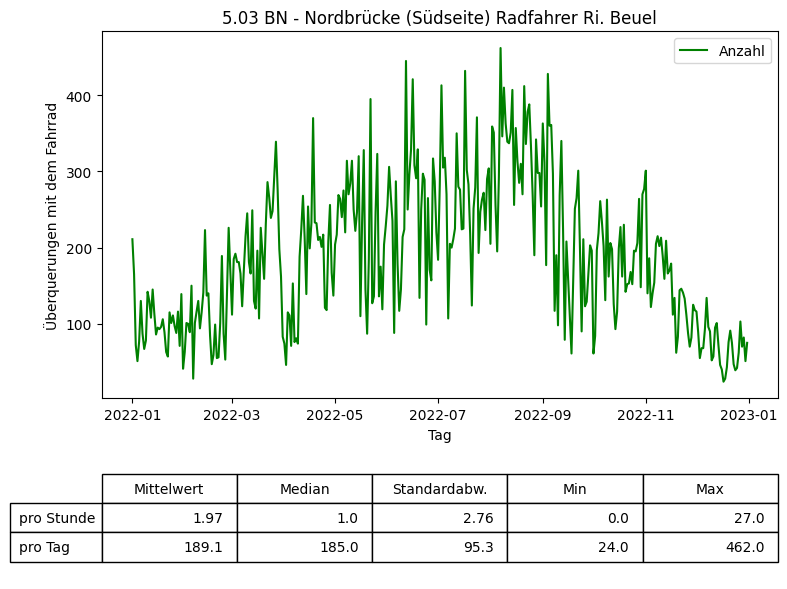

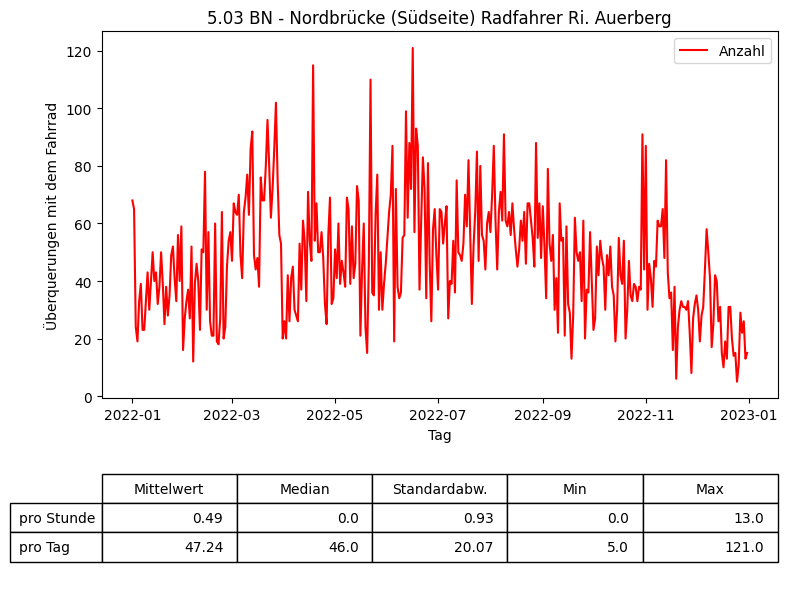

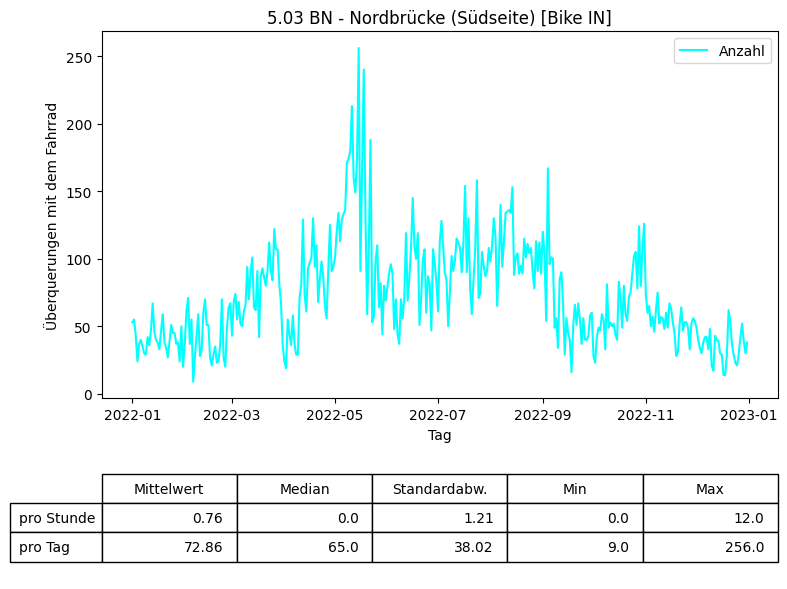

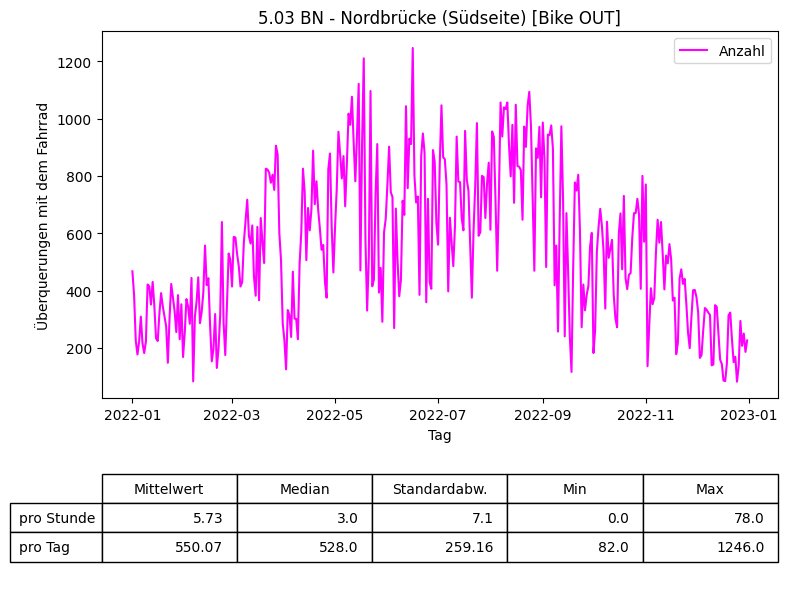

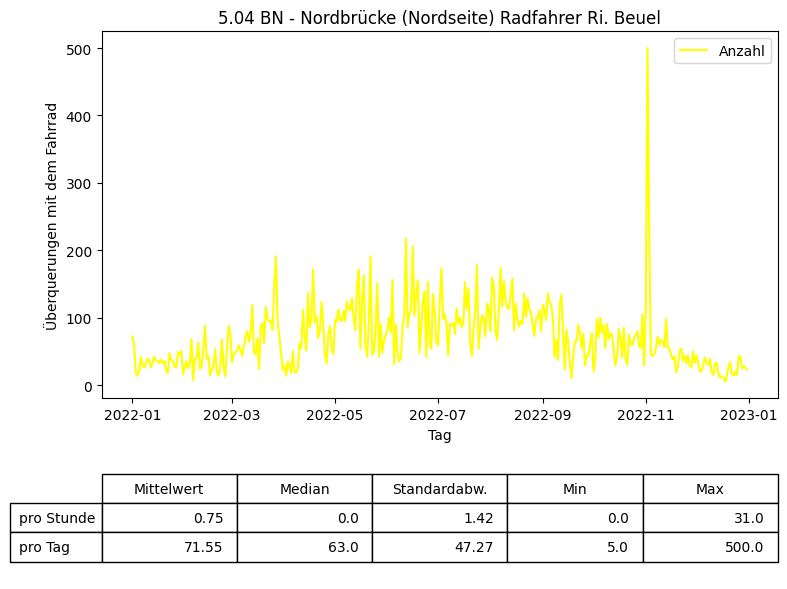

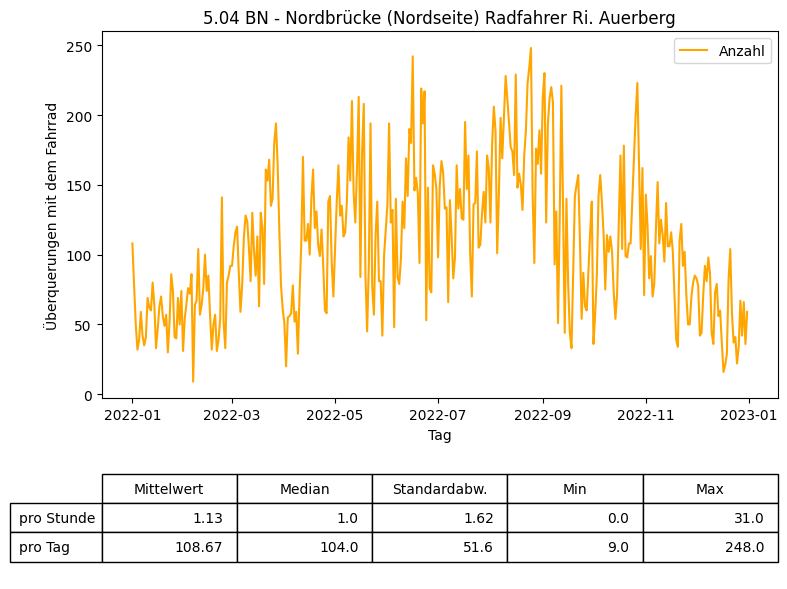

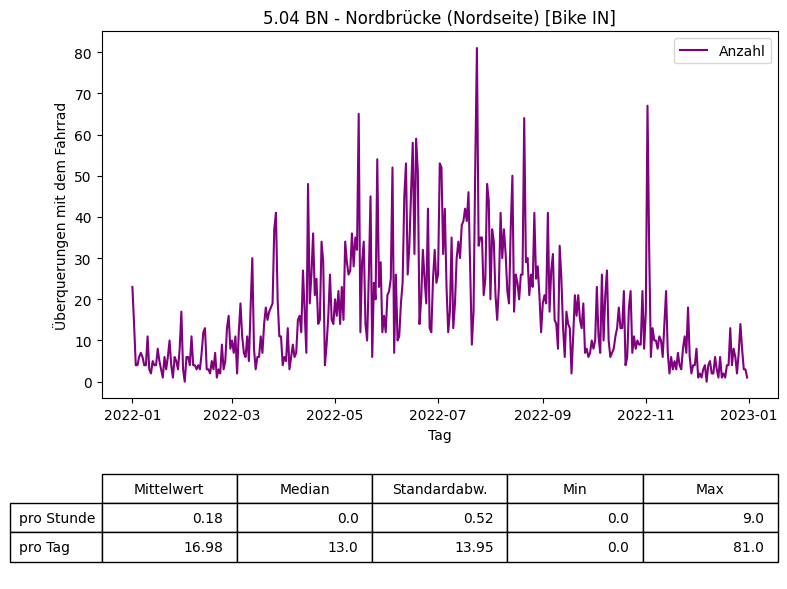

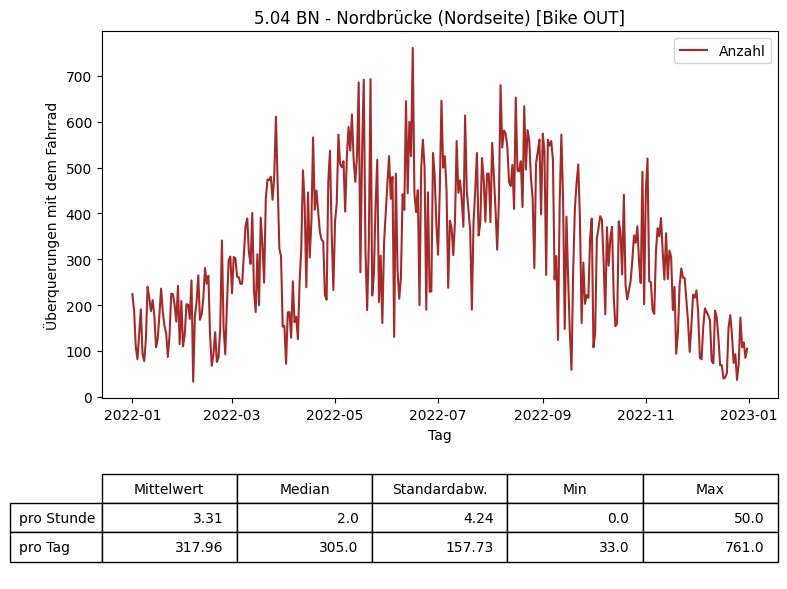

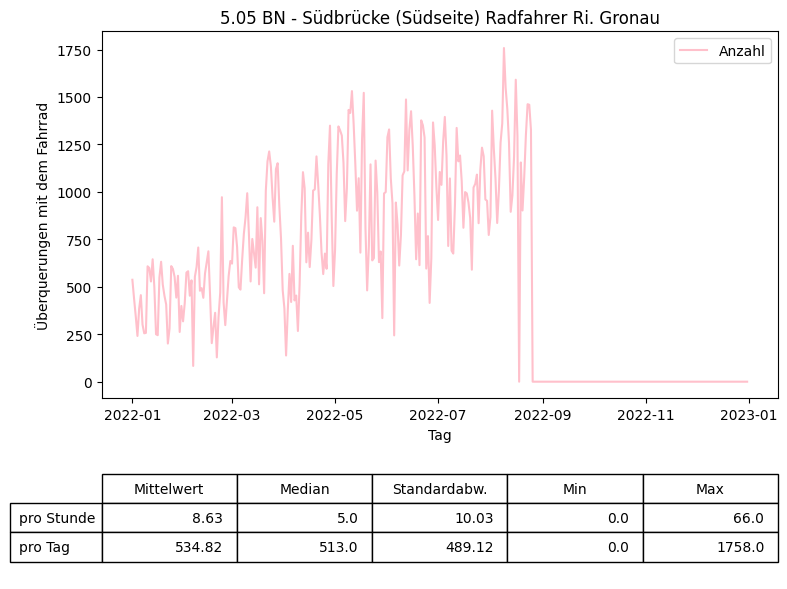

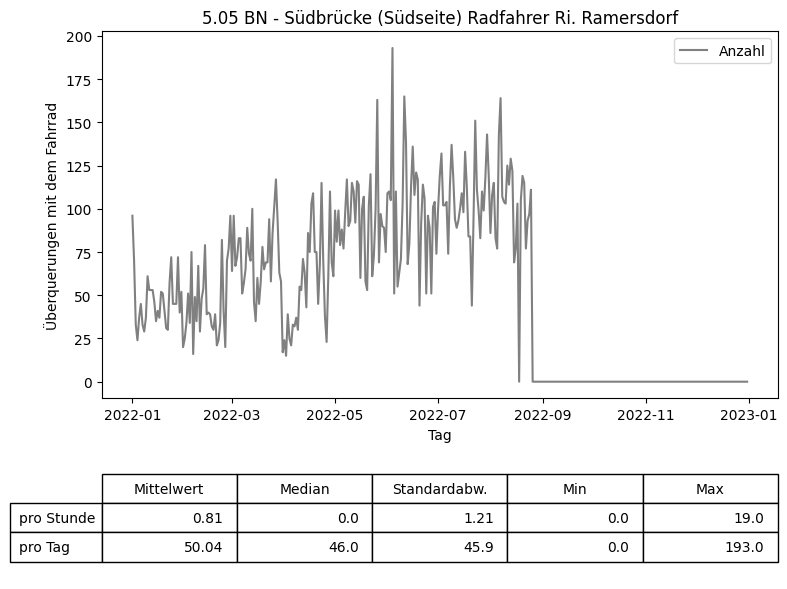

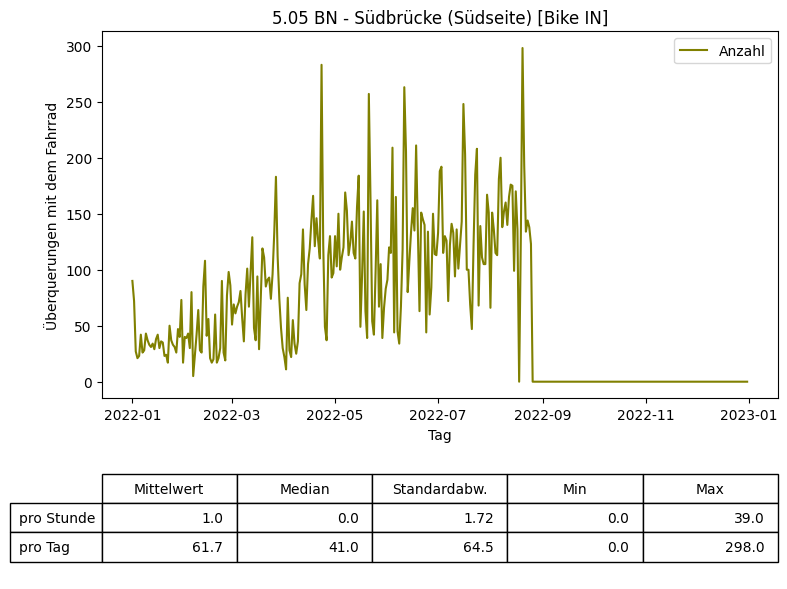

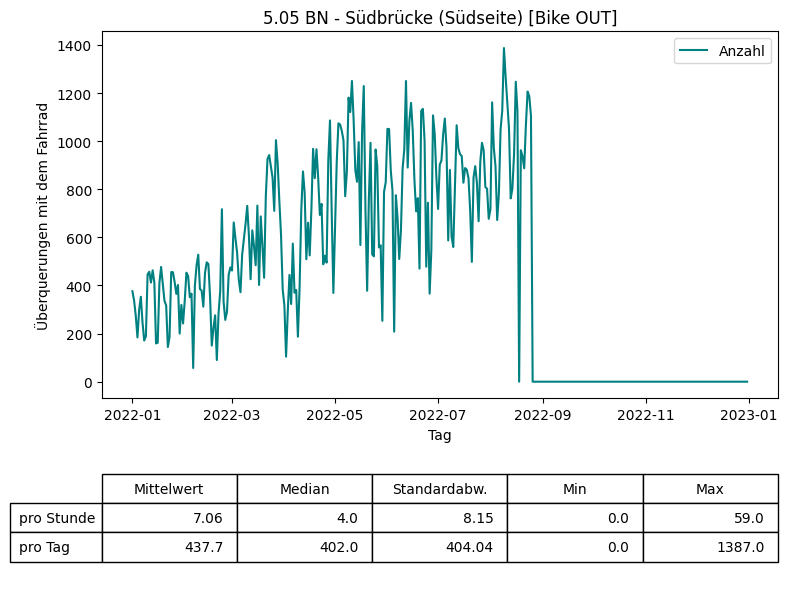

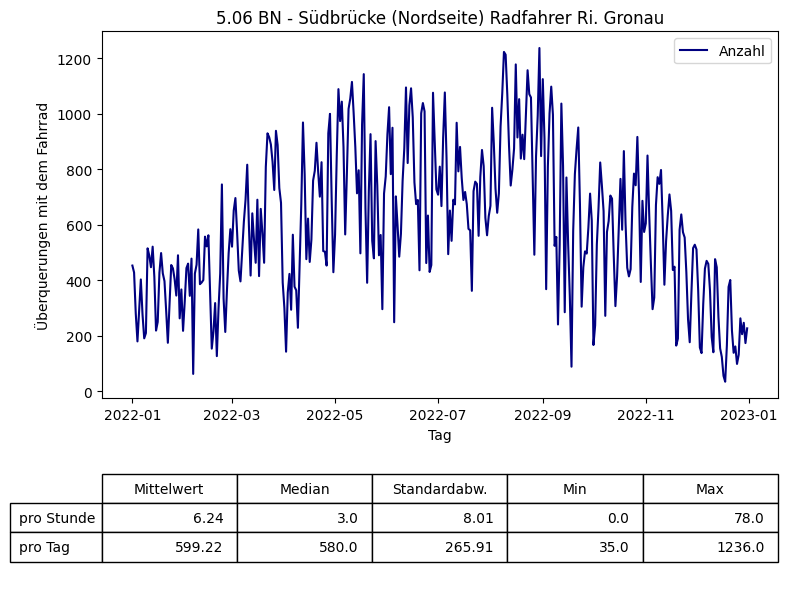

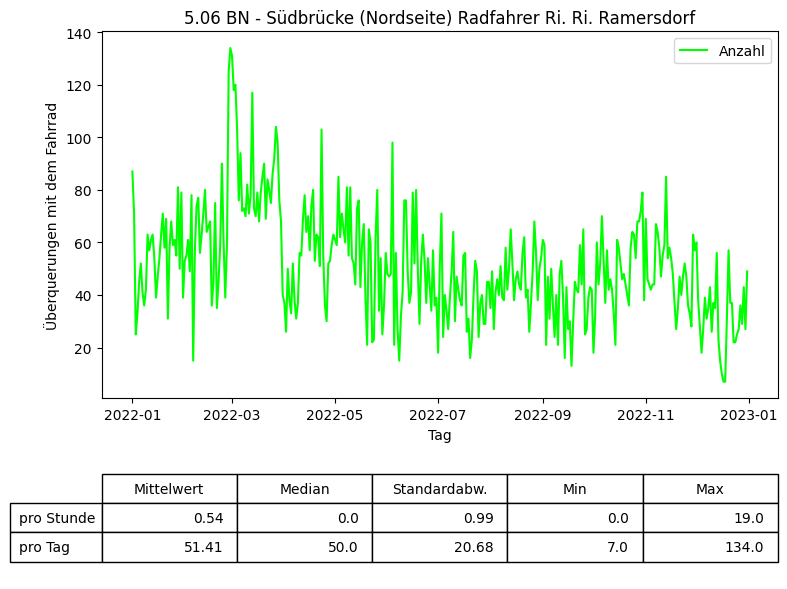

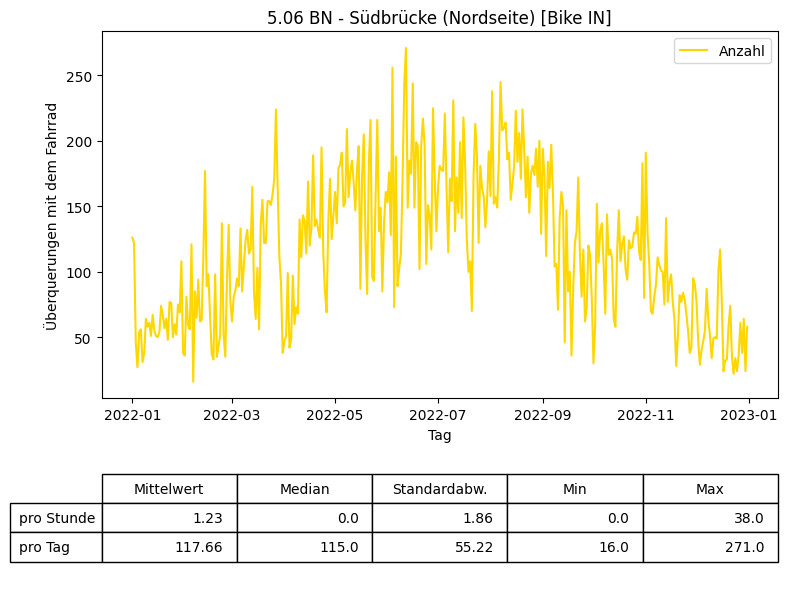

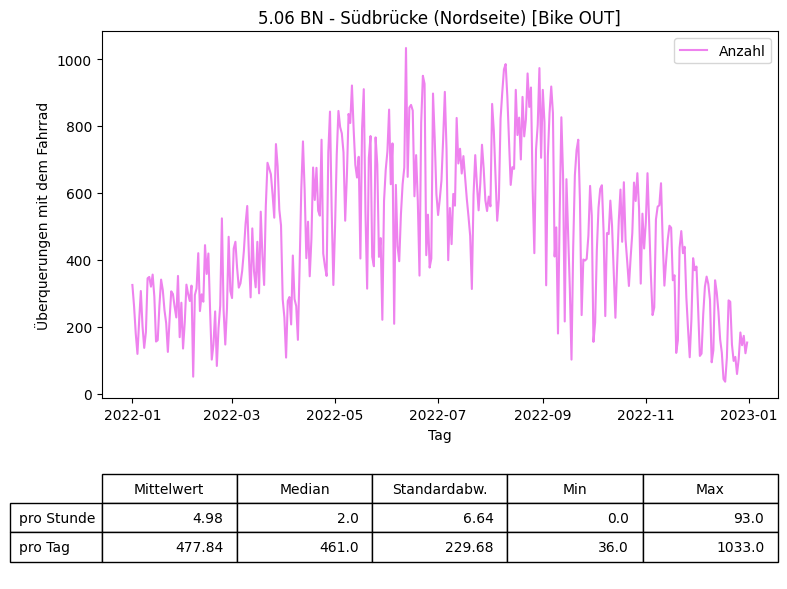

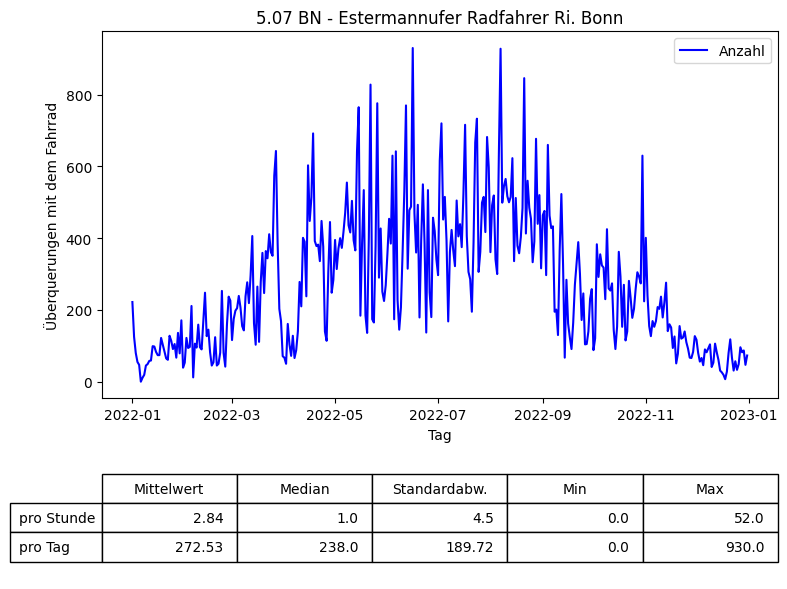

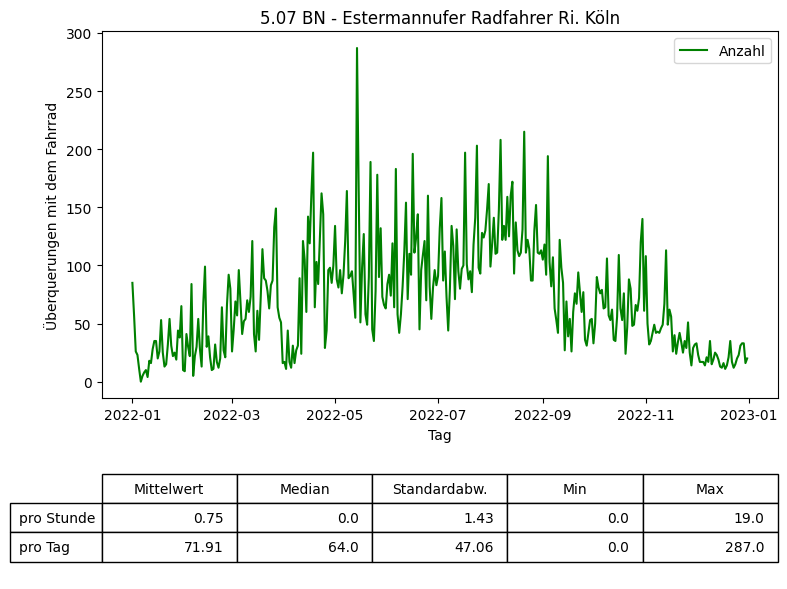

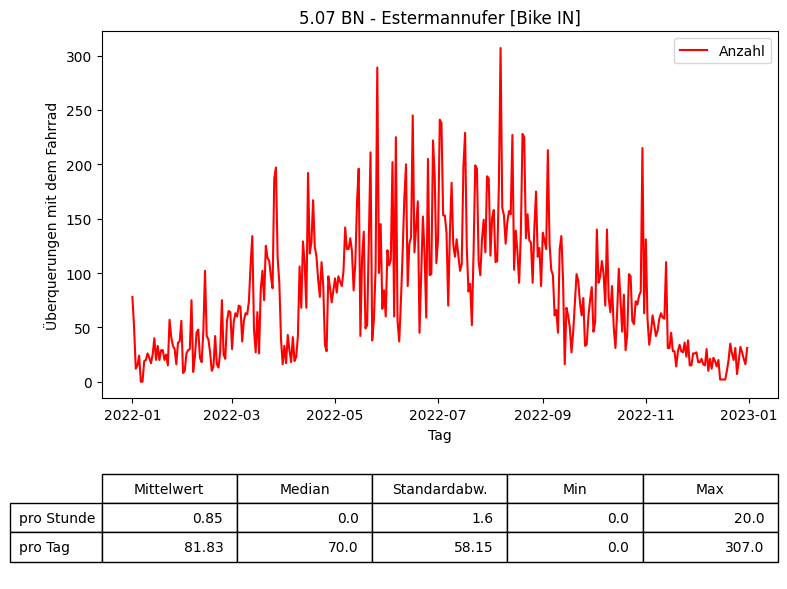

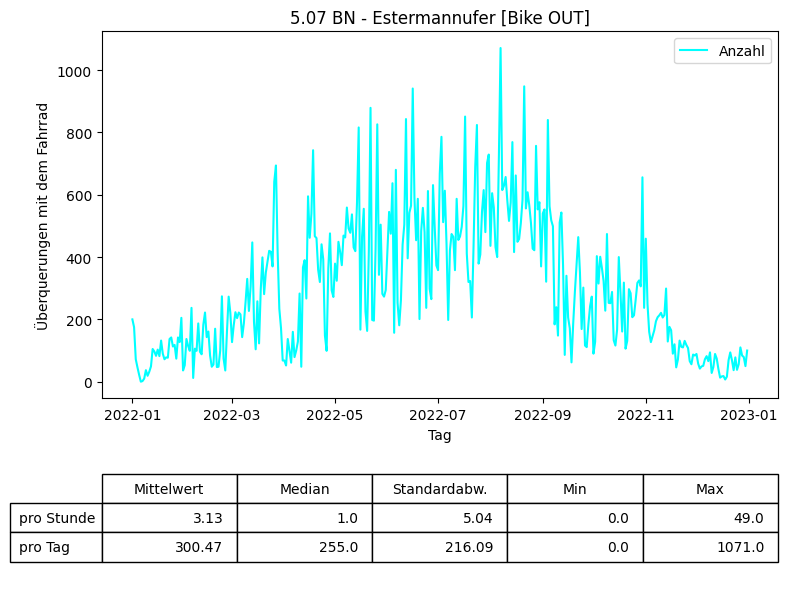

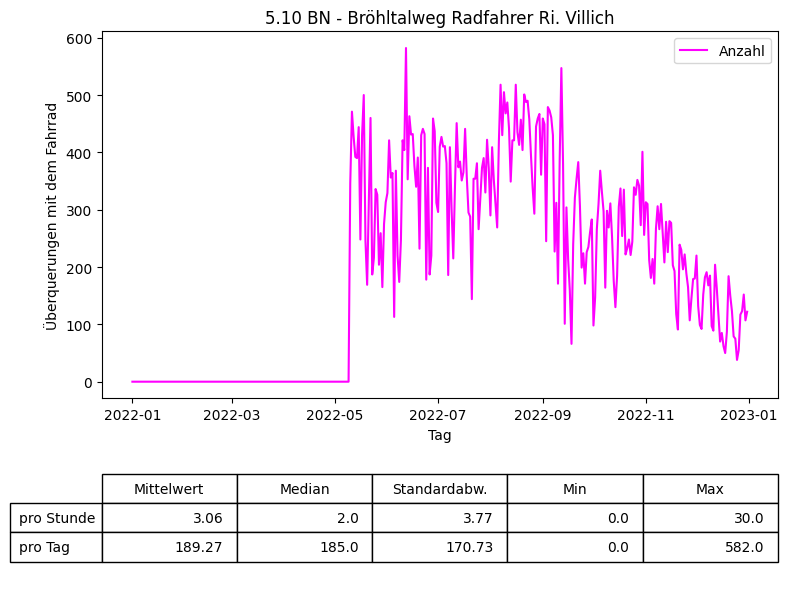

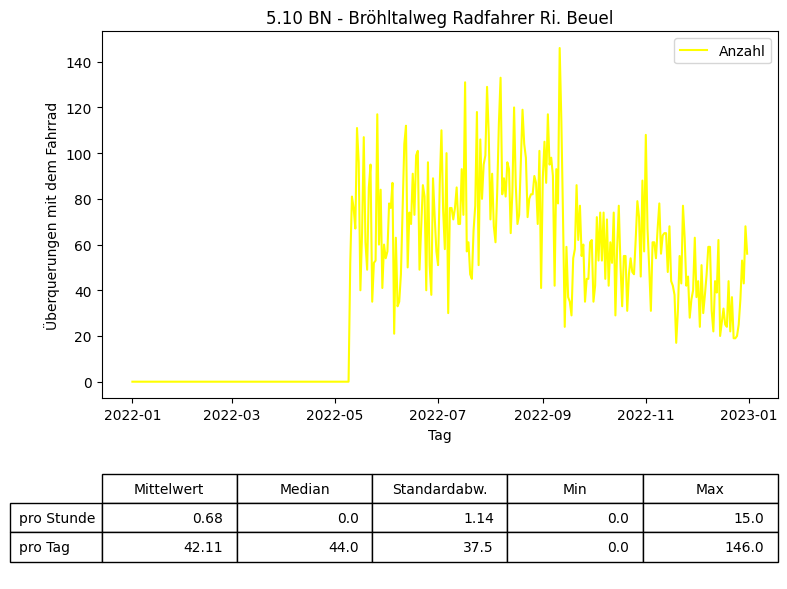

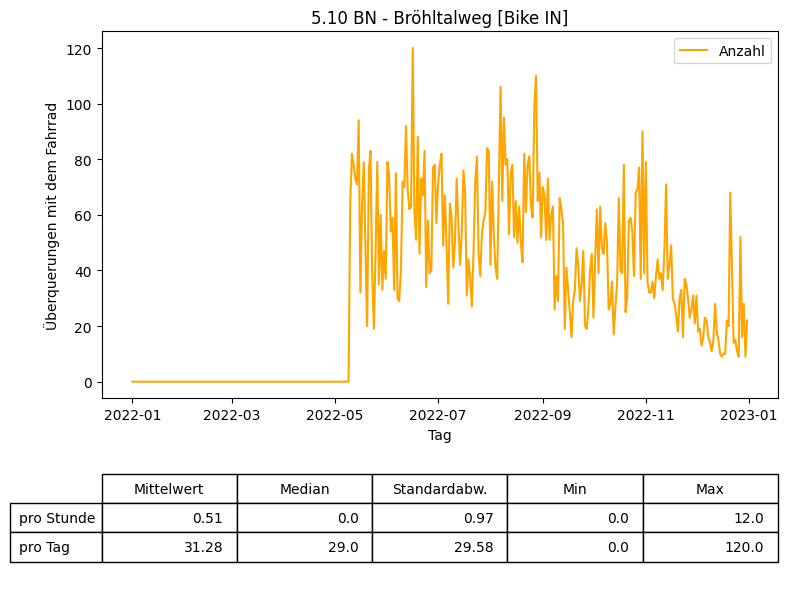

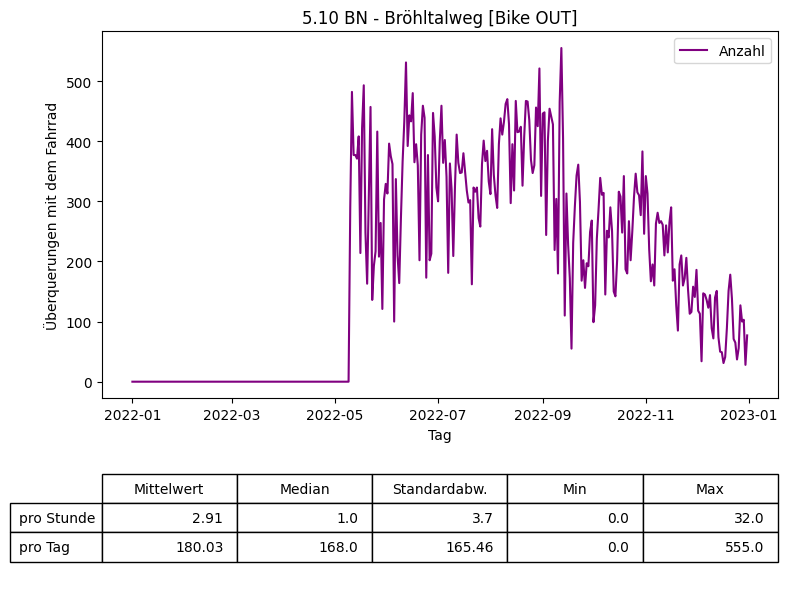

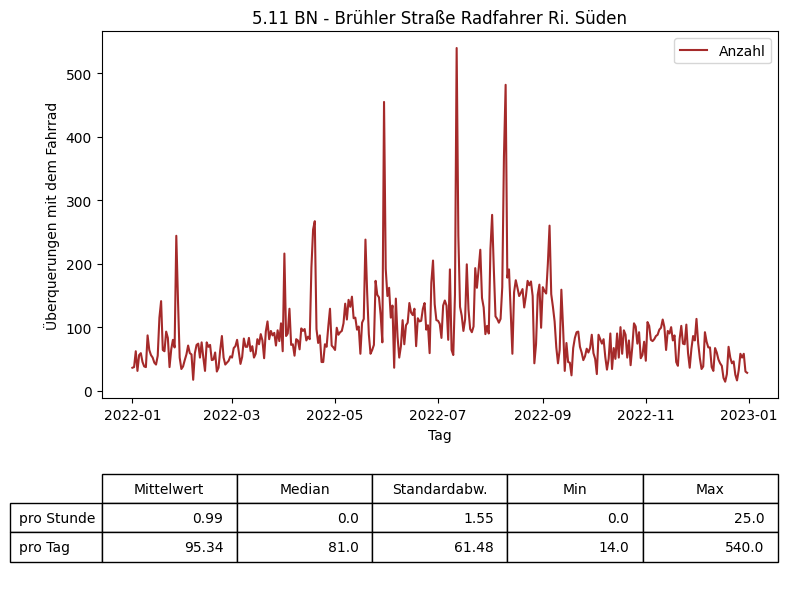

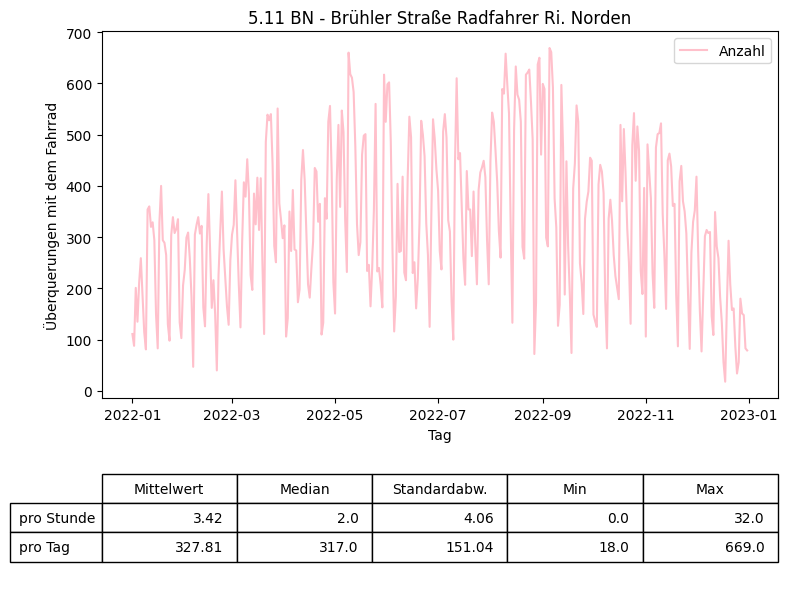

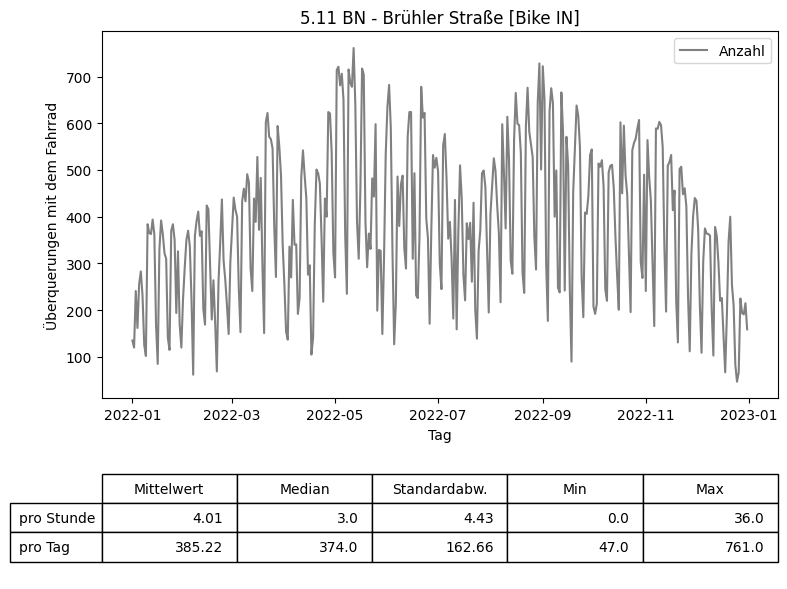

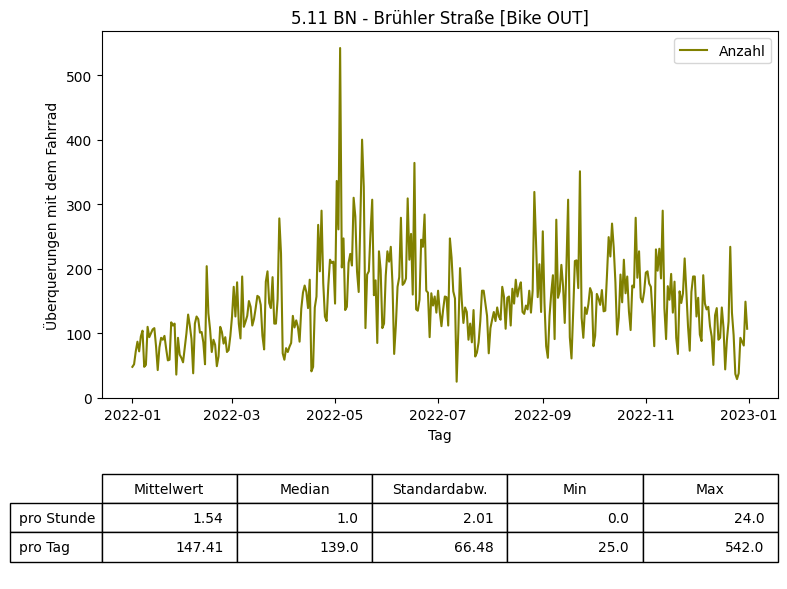

/home/leon/.var/app/com.jetbrains.PyCharm-Professional/cache/JetBrains/PyCharm2024.1/demo/PyCharmLearningProject/venv/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1241: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


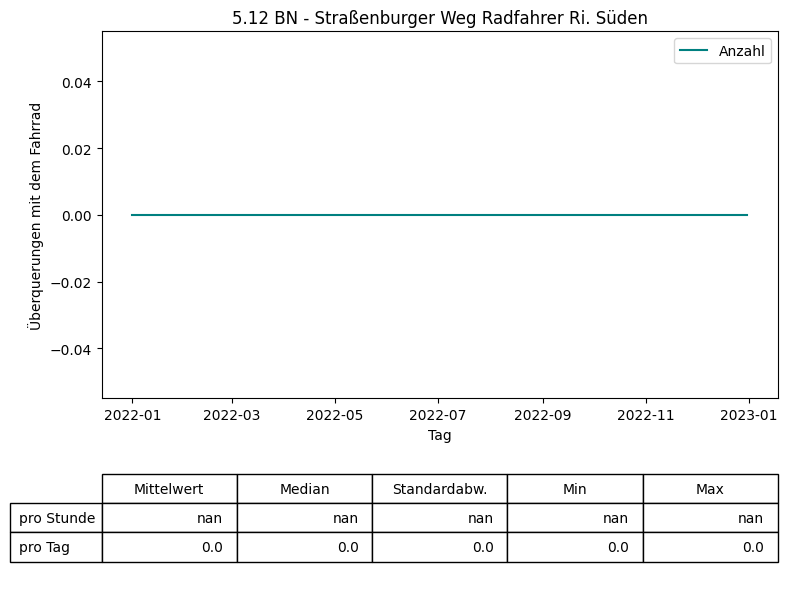

/home/leon/.var/app/com.jetbrains.PyCharm-Professional/cache/JetBrains/PyCharm2024.1/demo/PyCharmLearningProject/venv/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1241: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


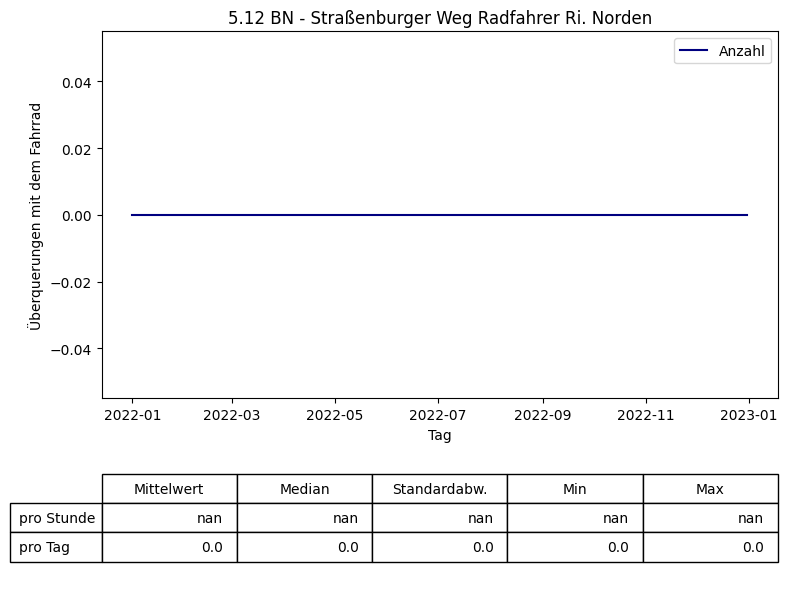

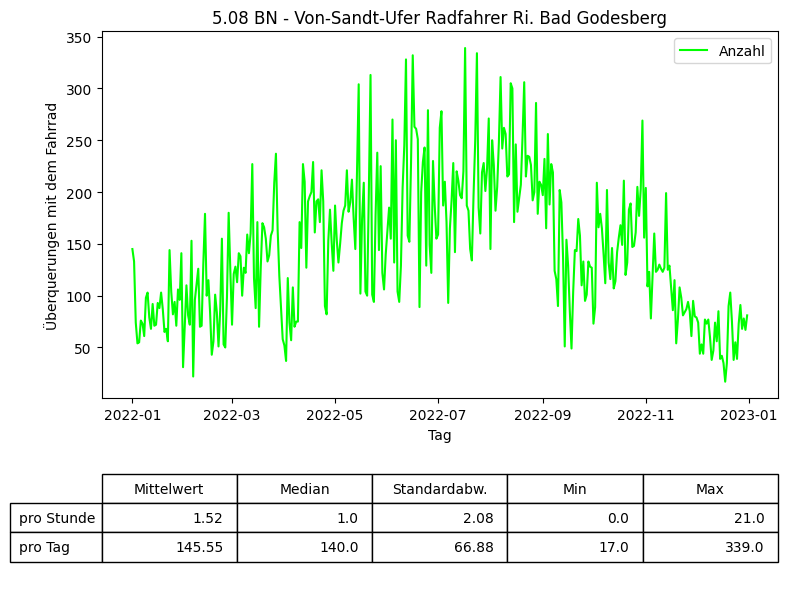

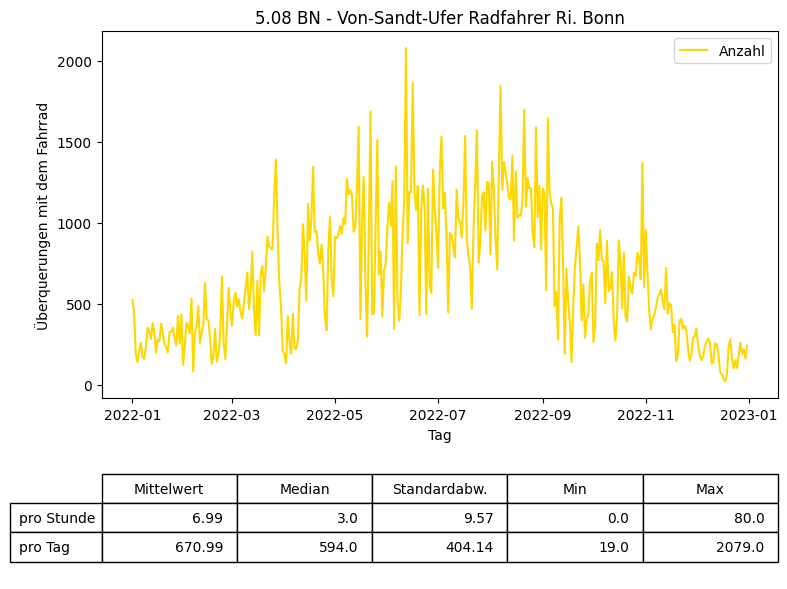

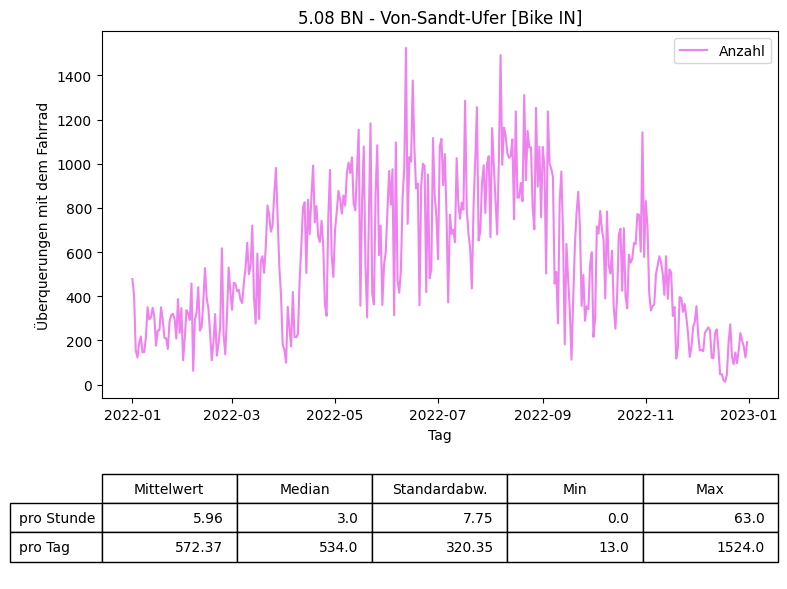

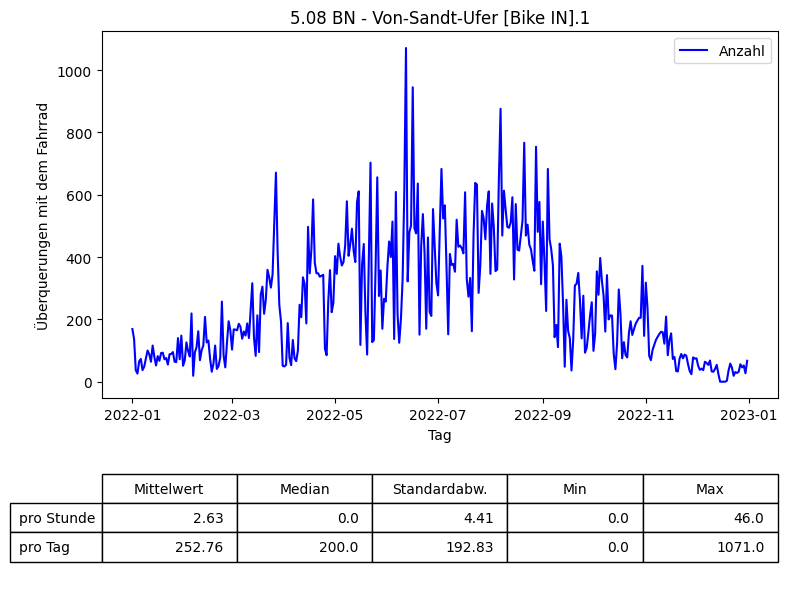

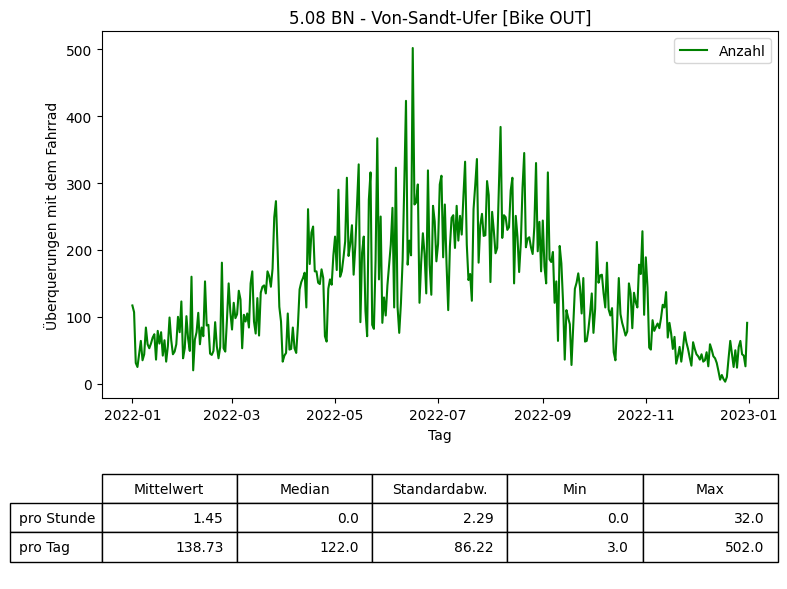

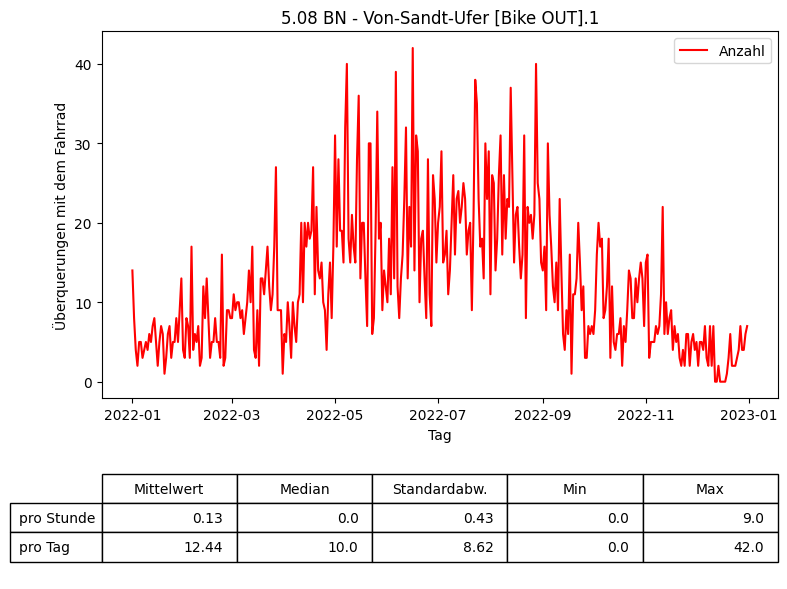

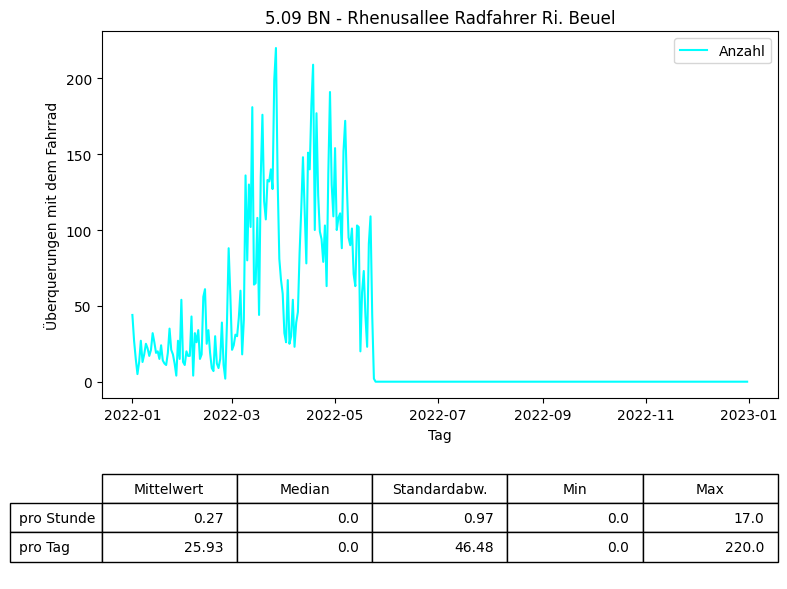

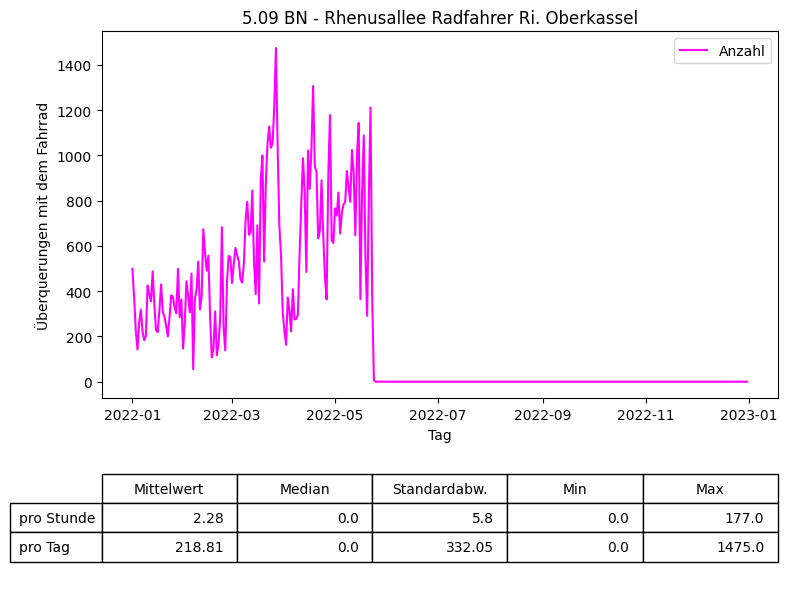

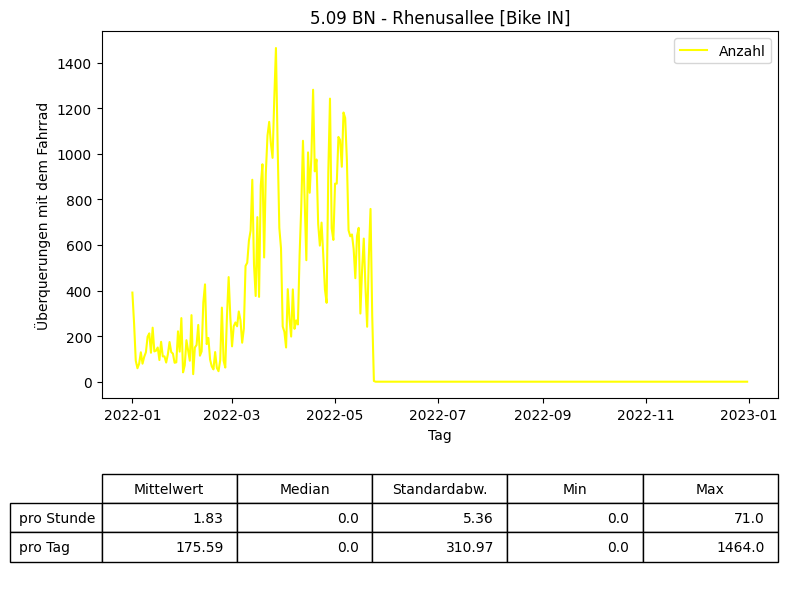

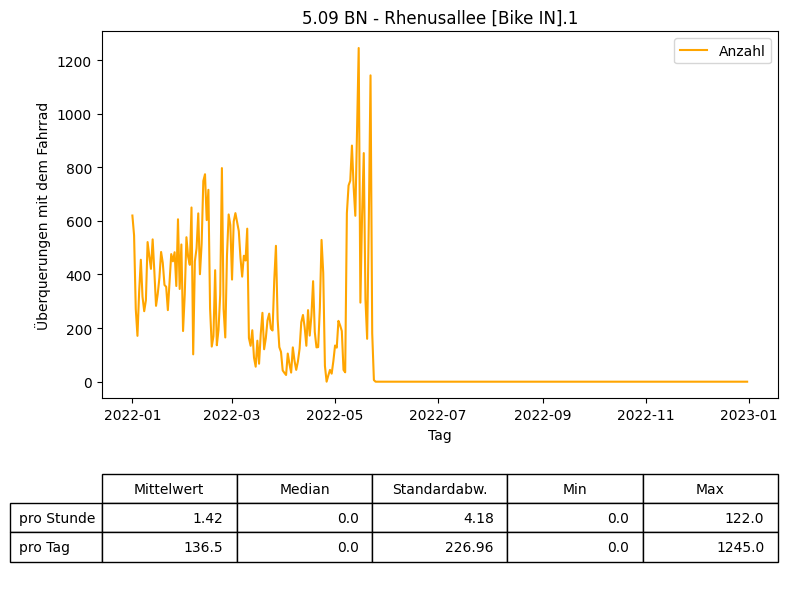

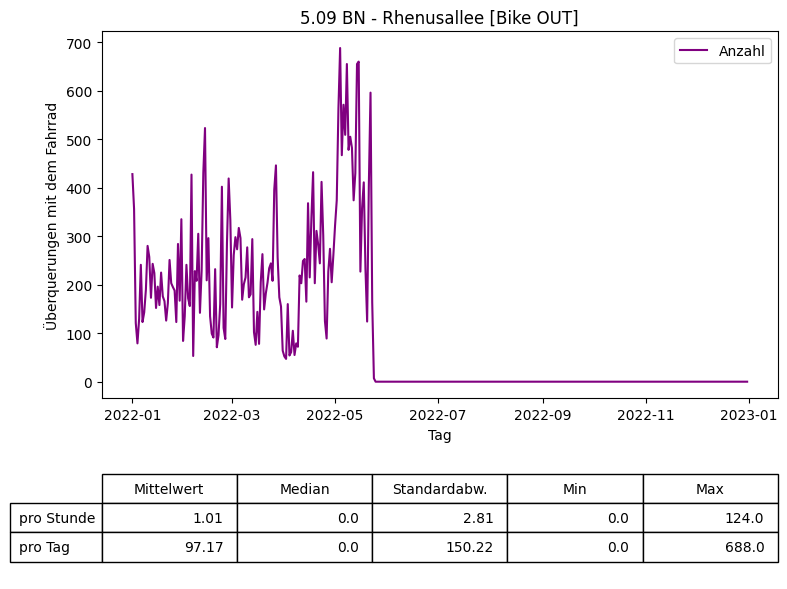

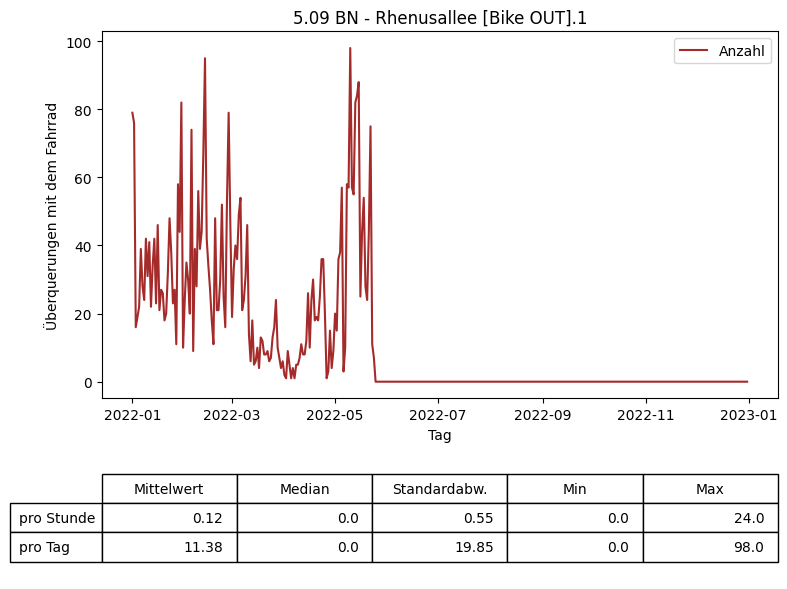

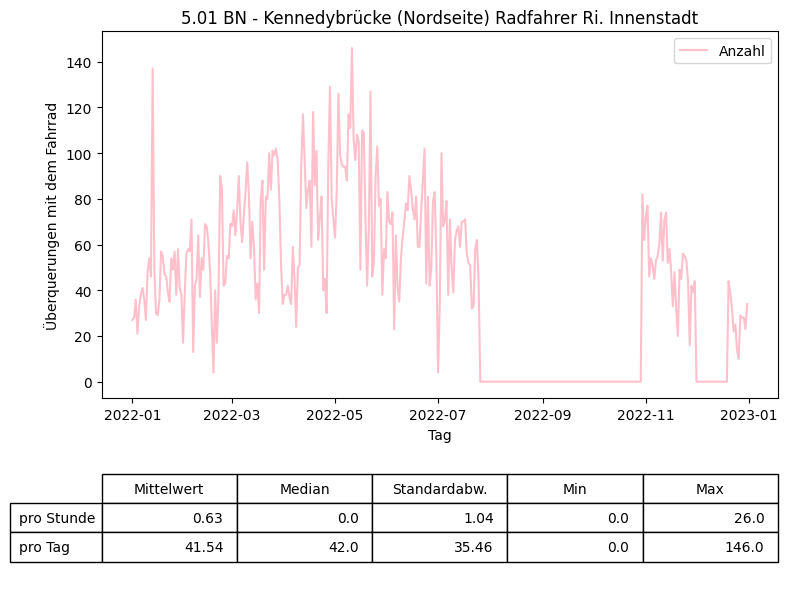

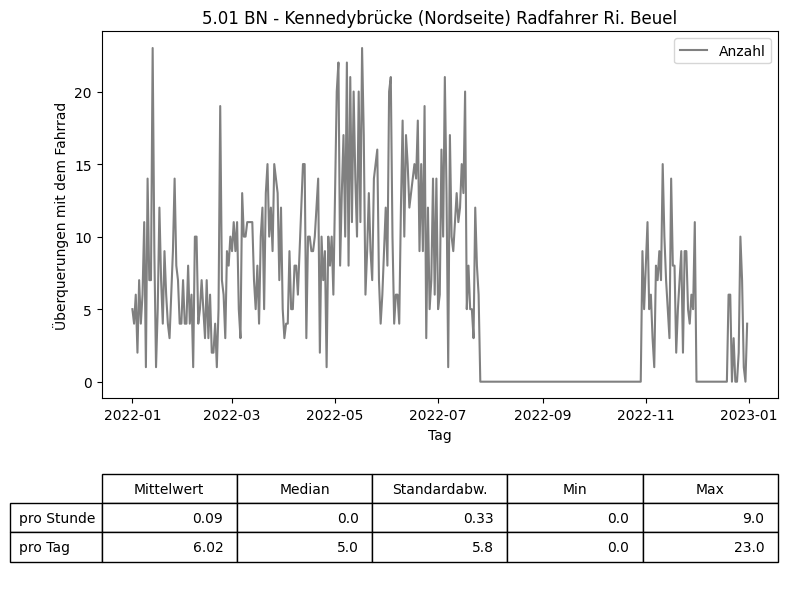

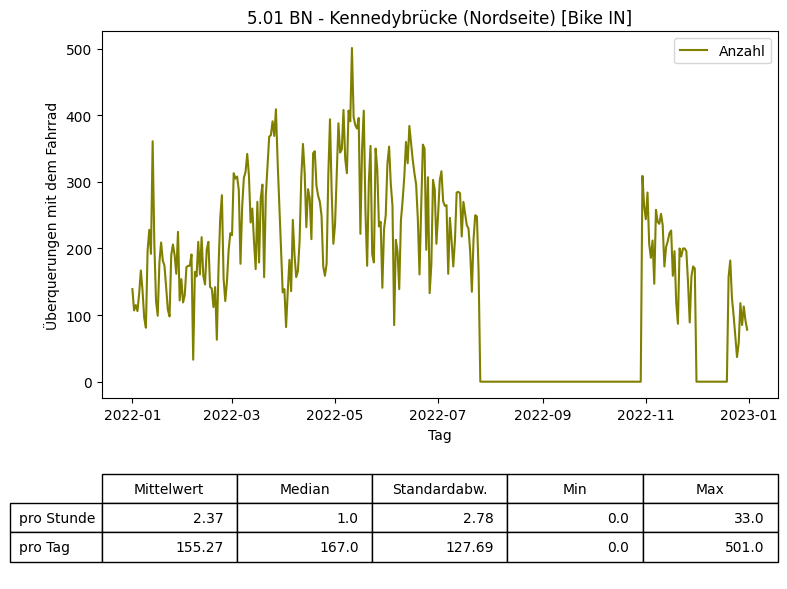

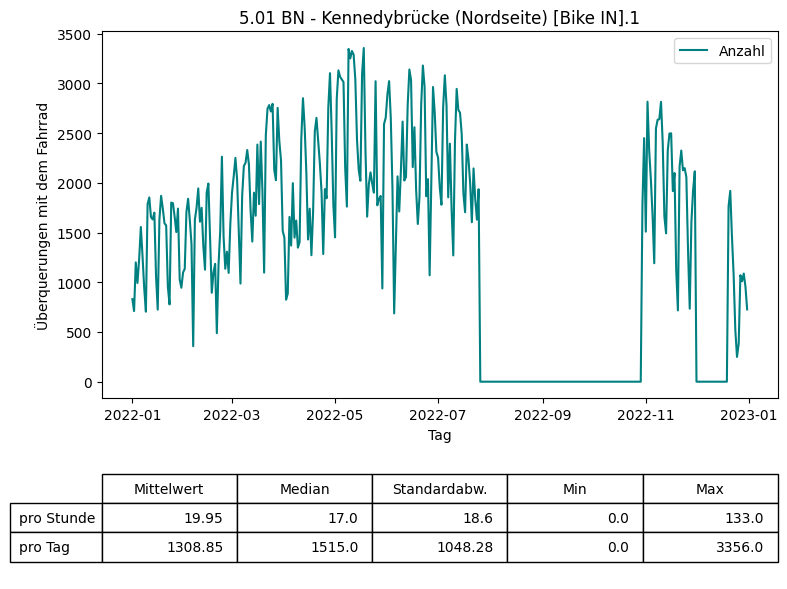

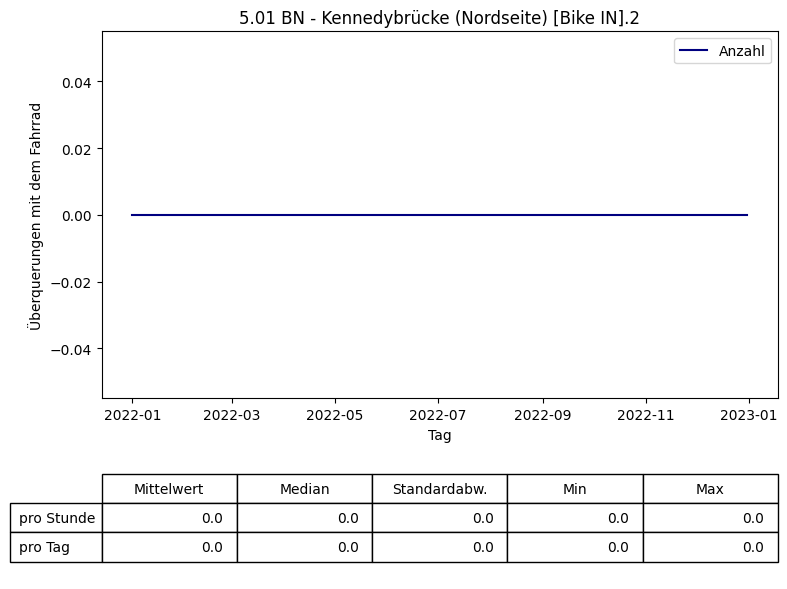

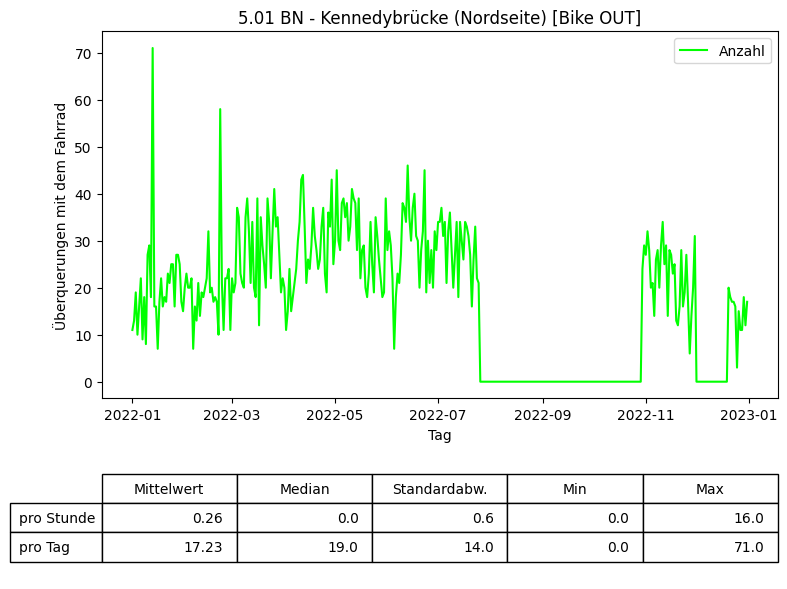

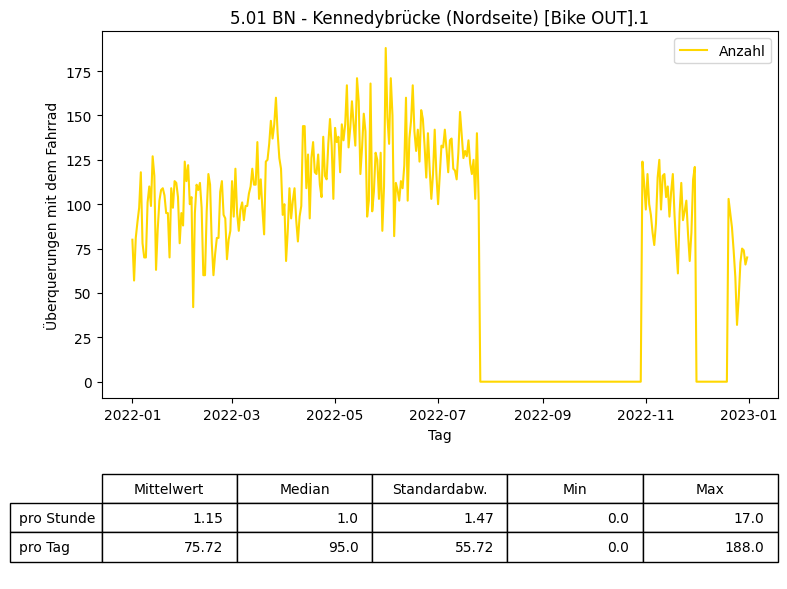

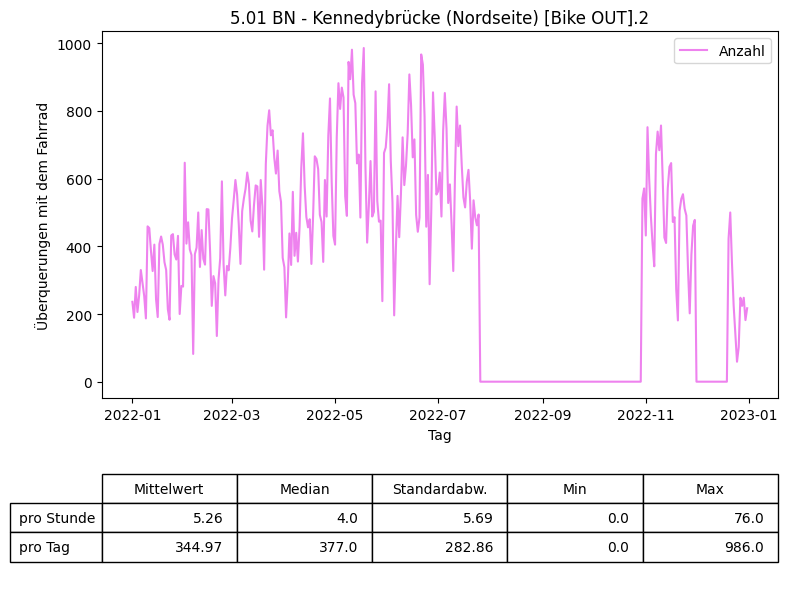

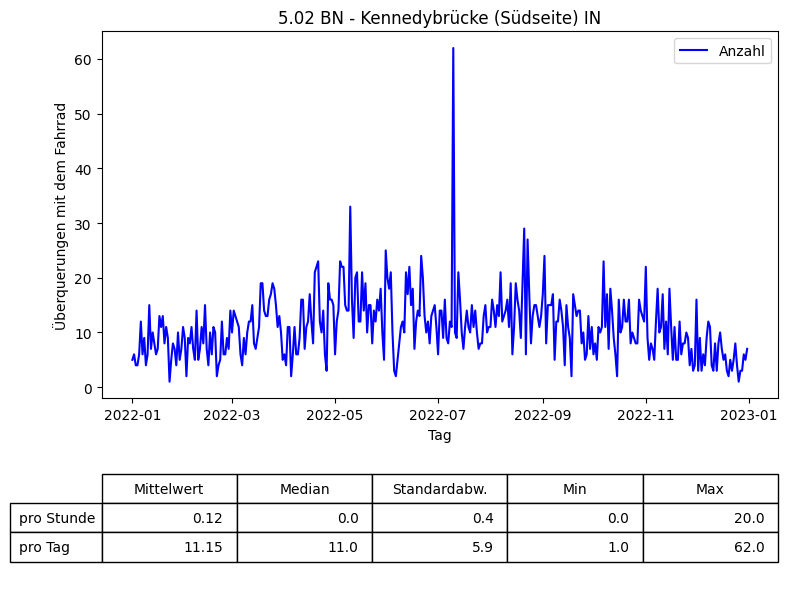

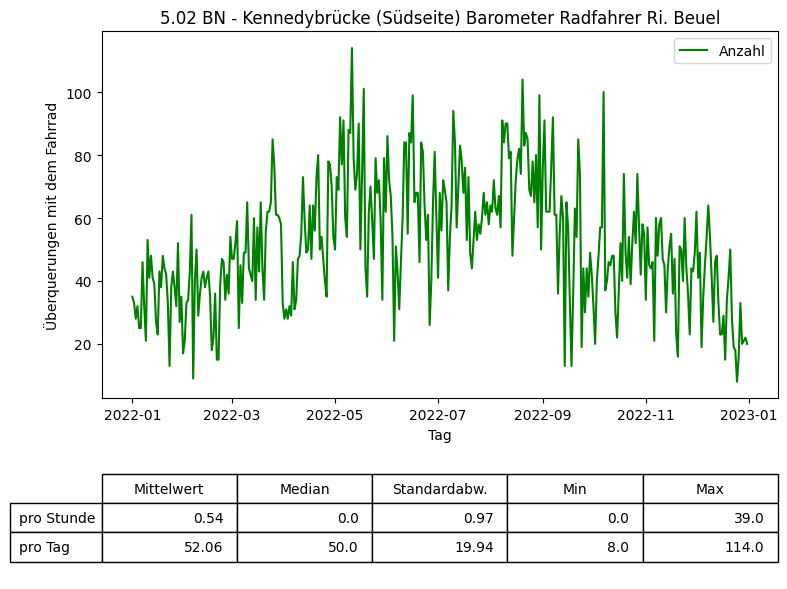

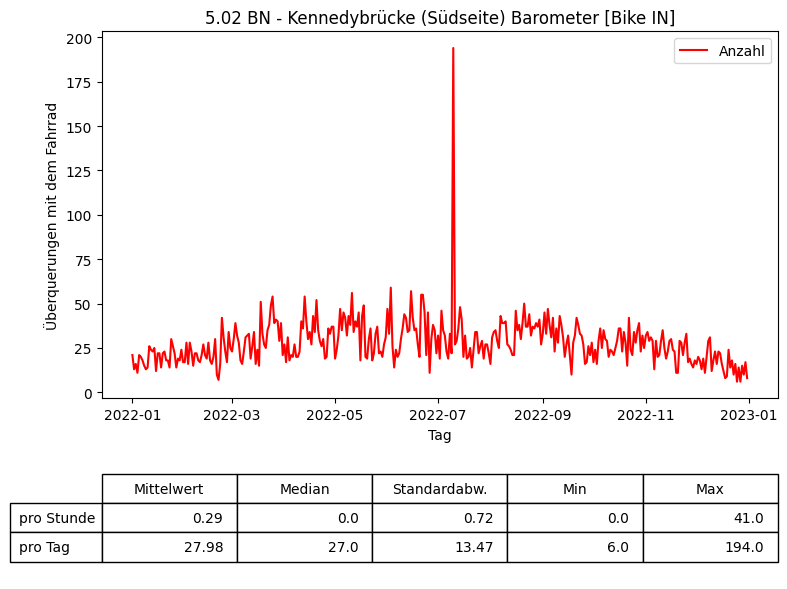

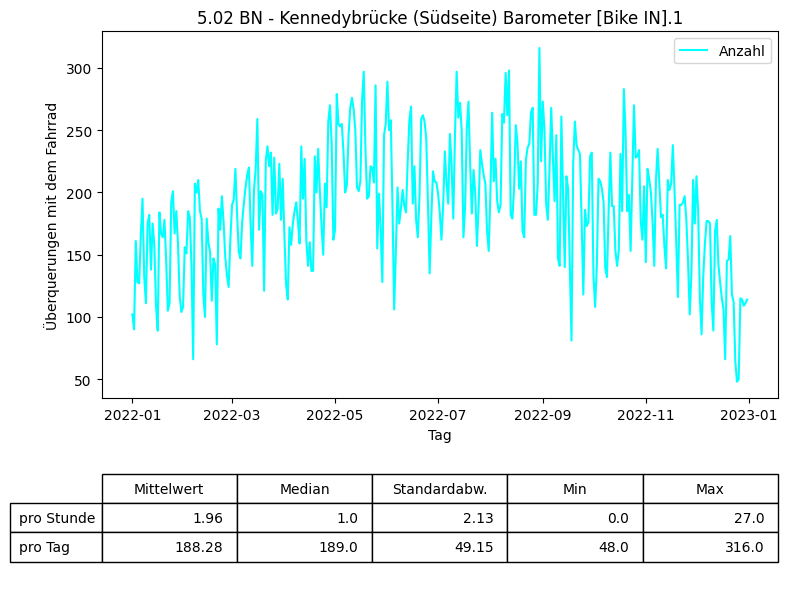

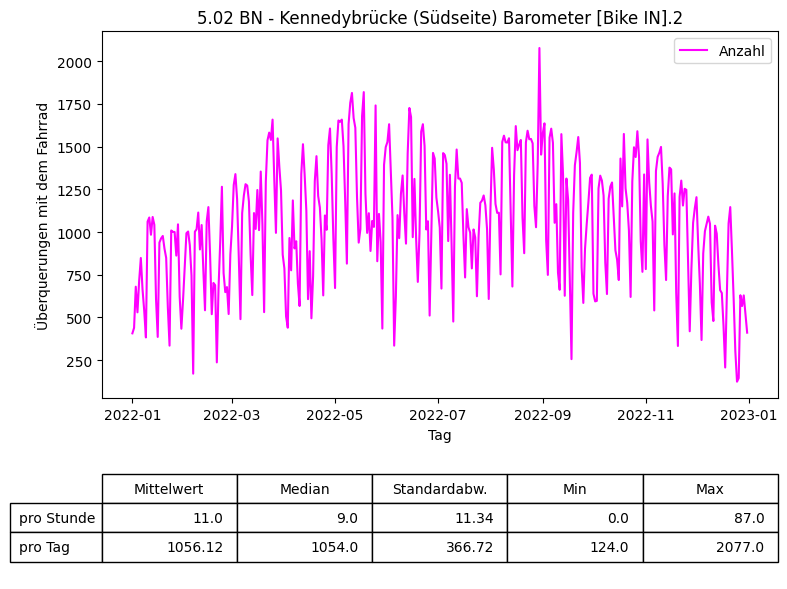

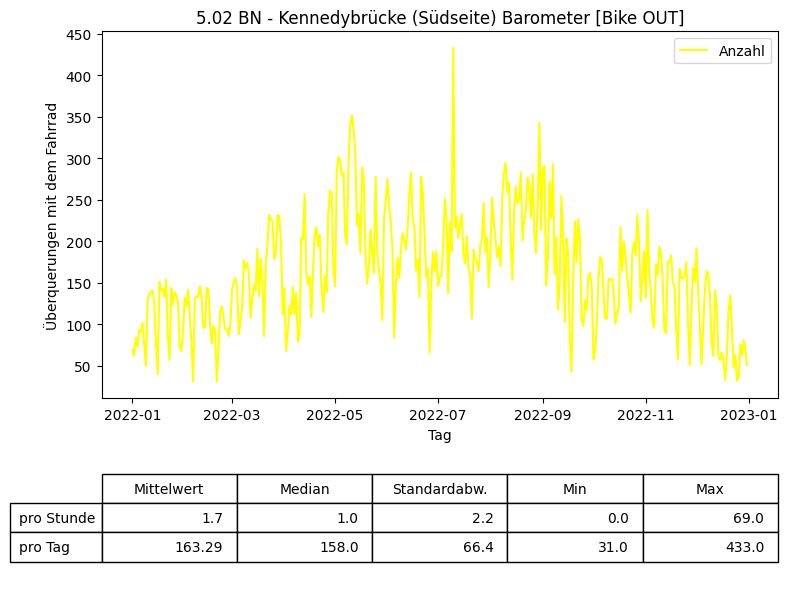

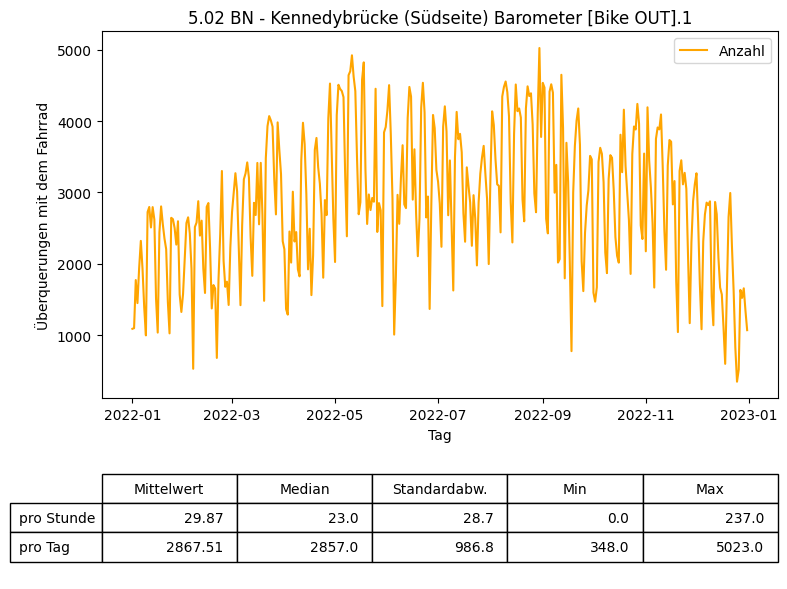

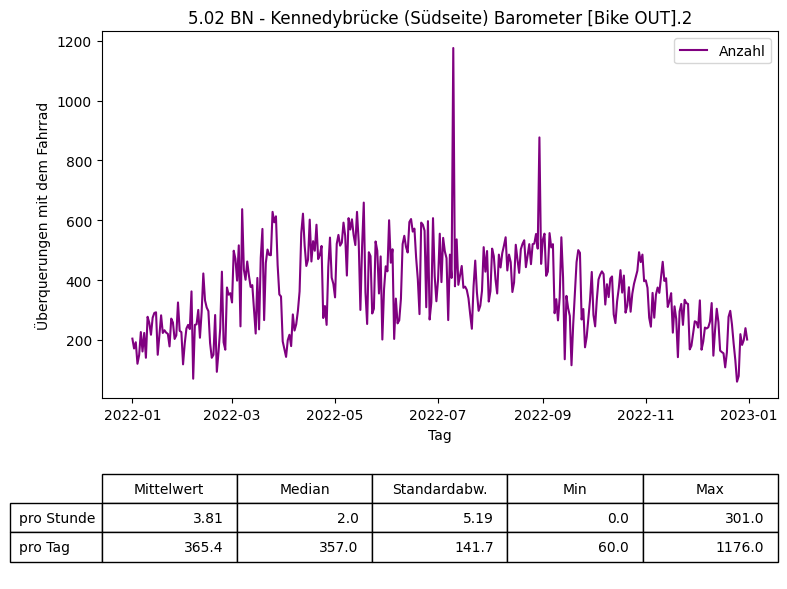

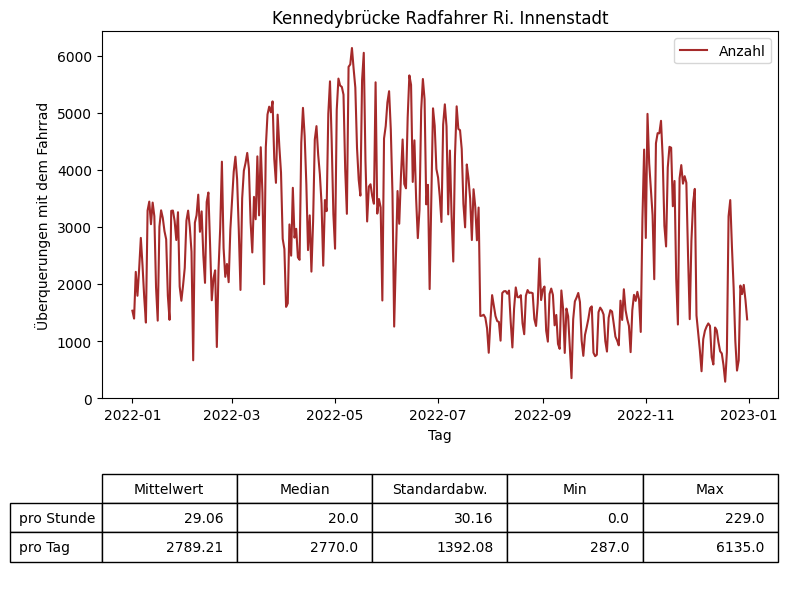

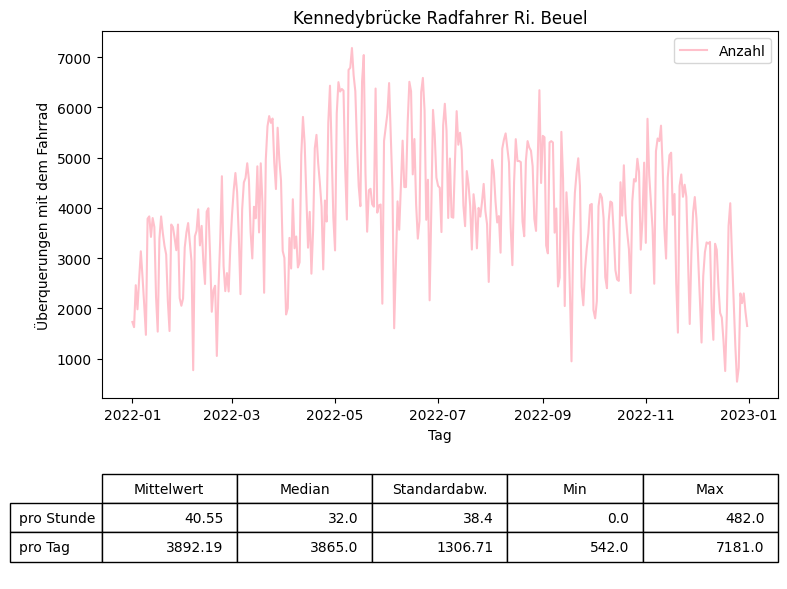

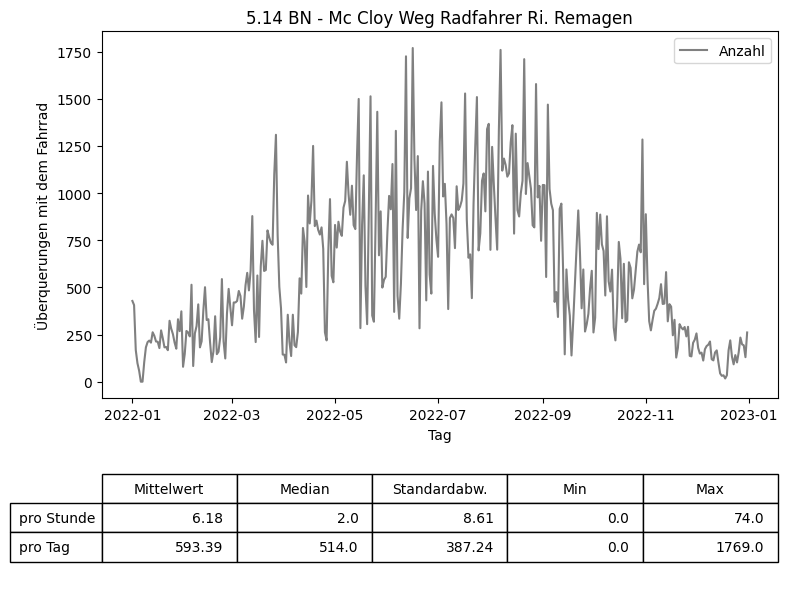

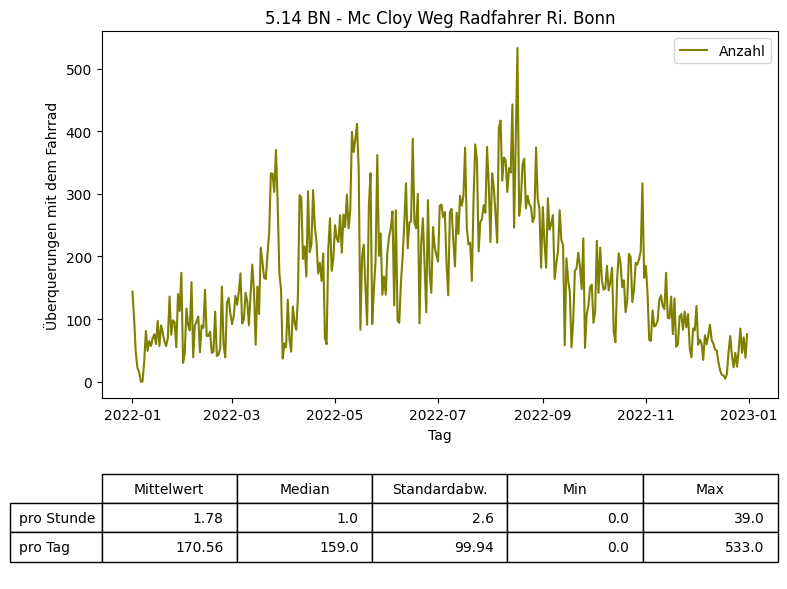

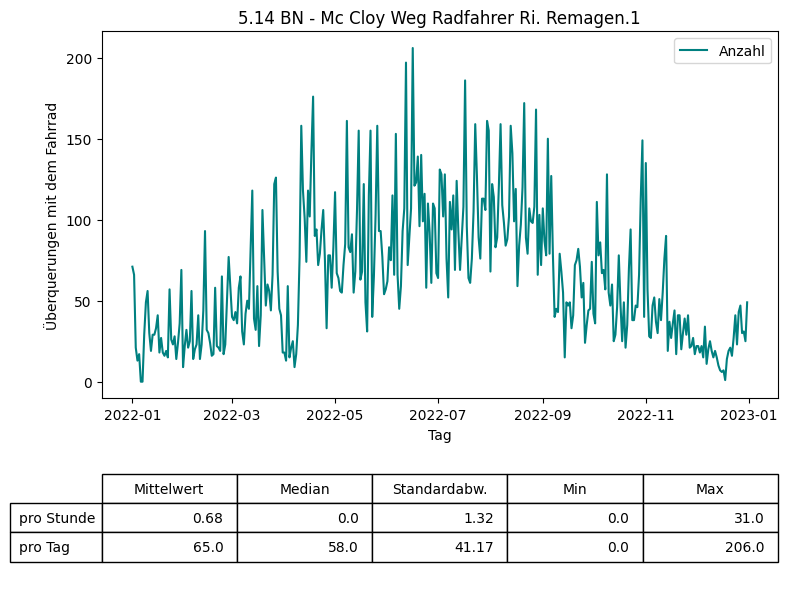

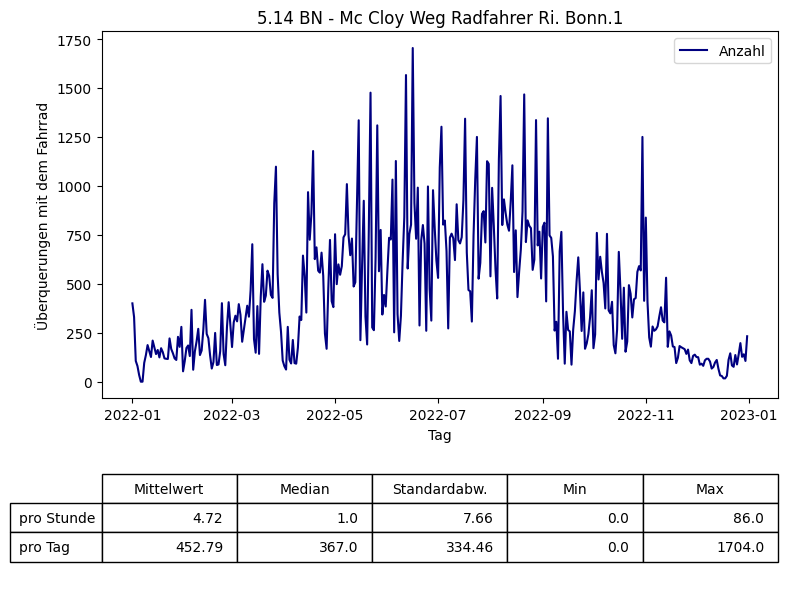

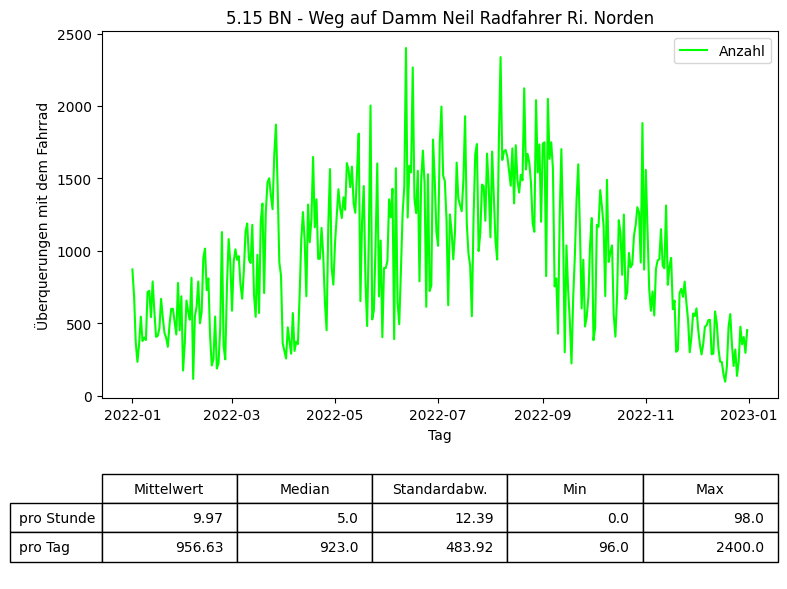

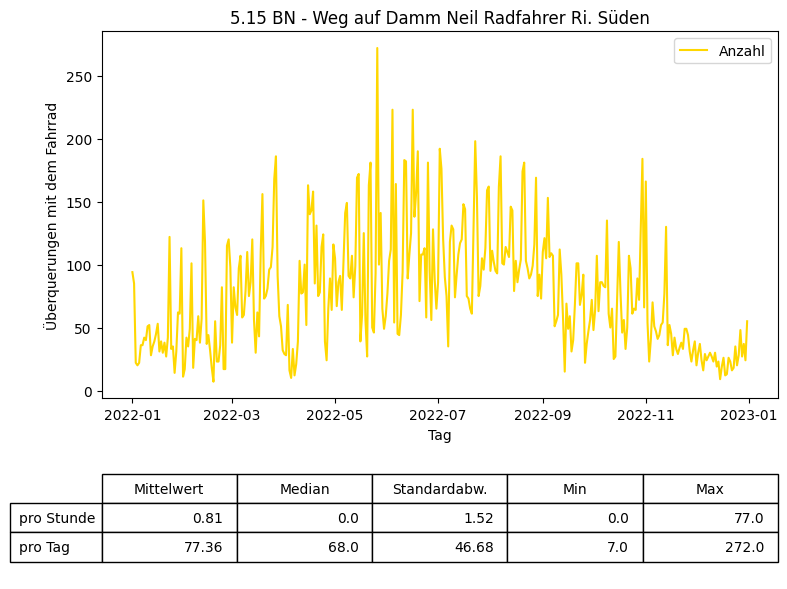

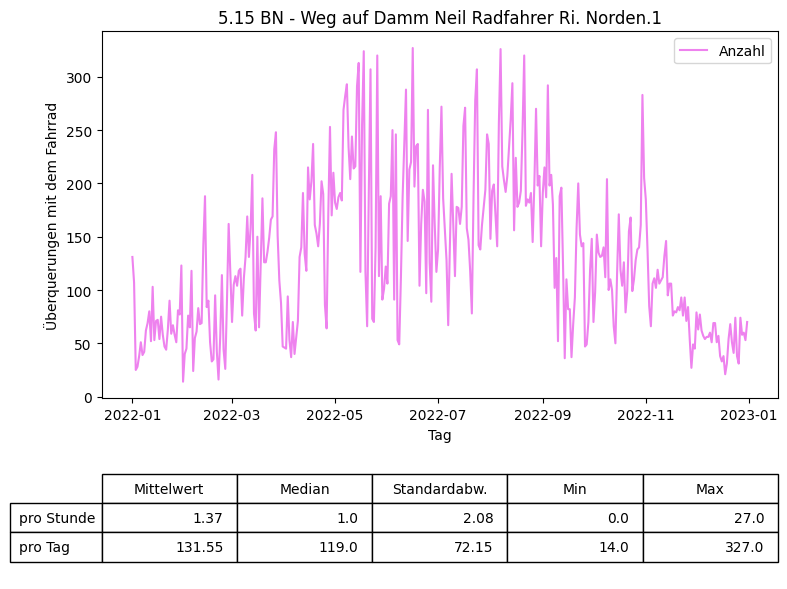

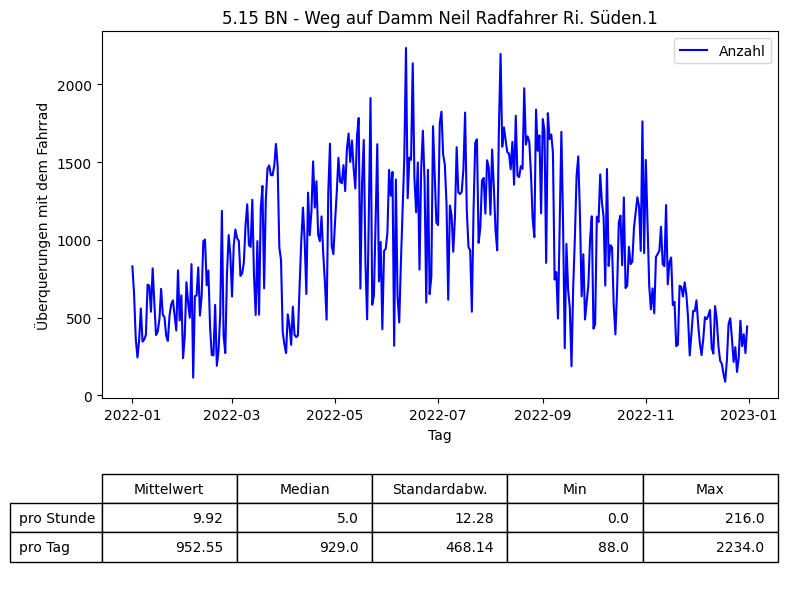

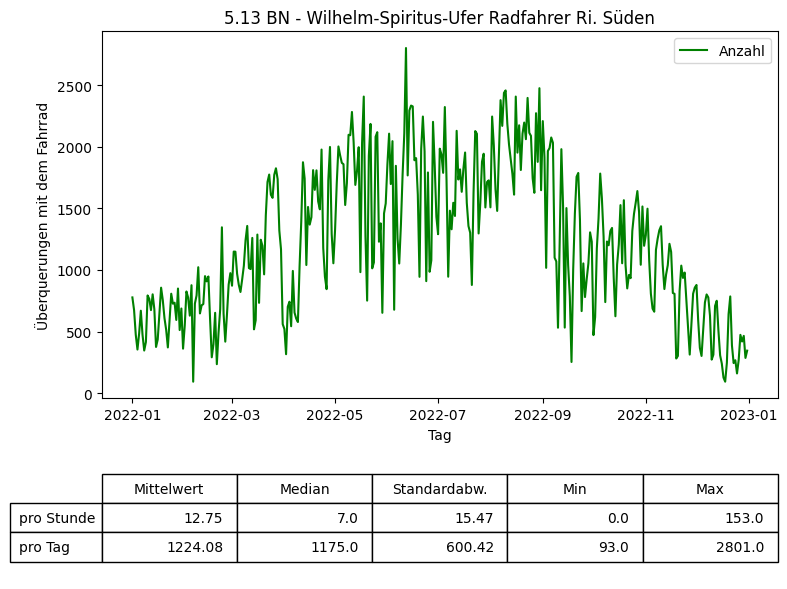

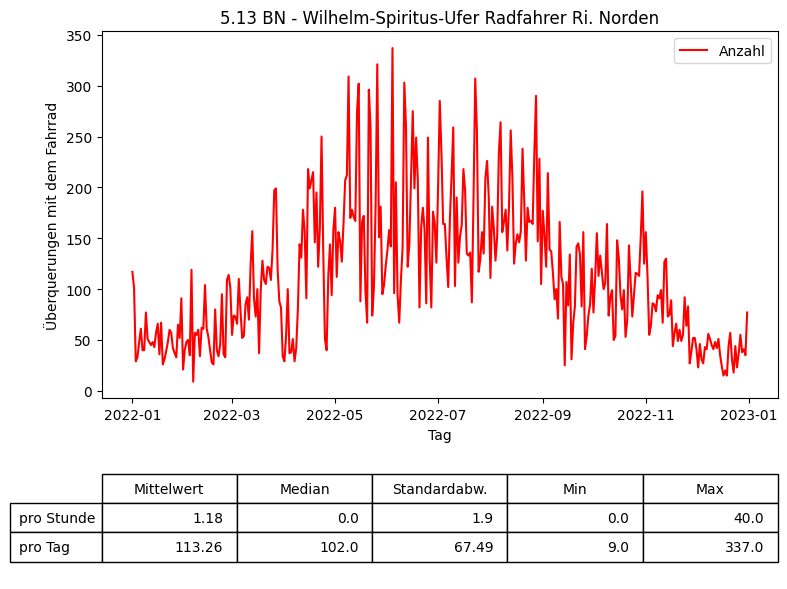

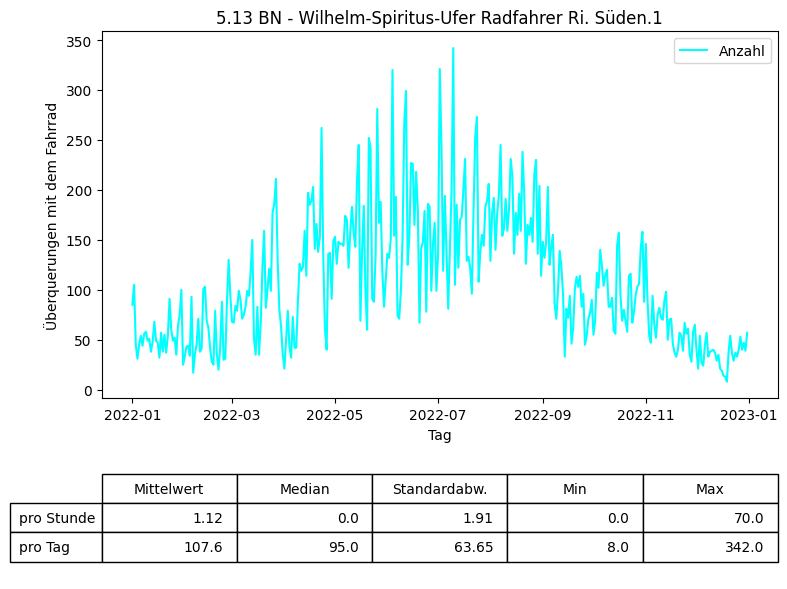

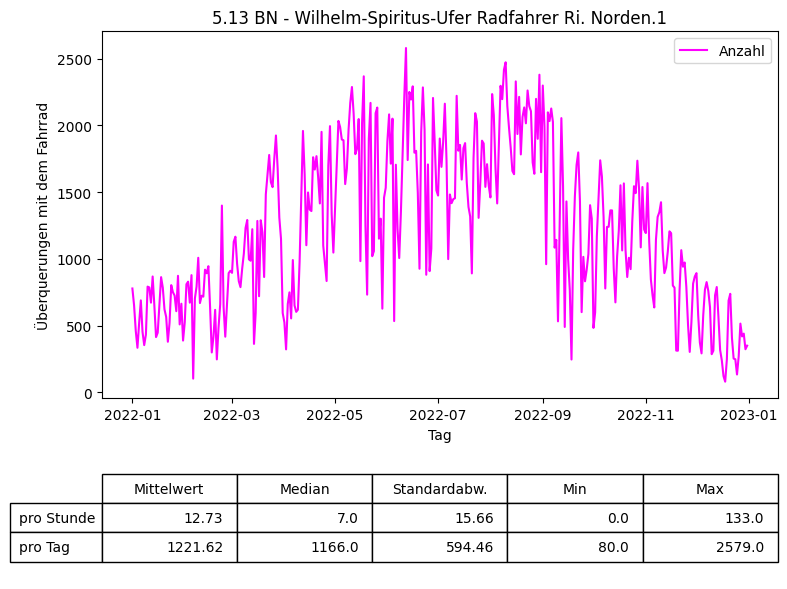

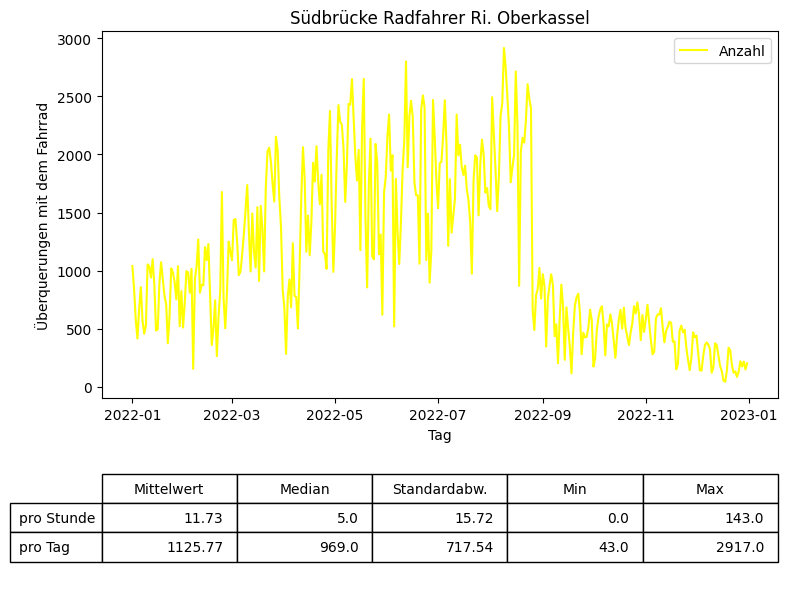

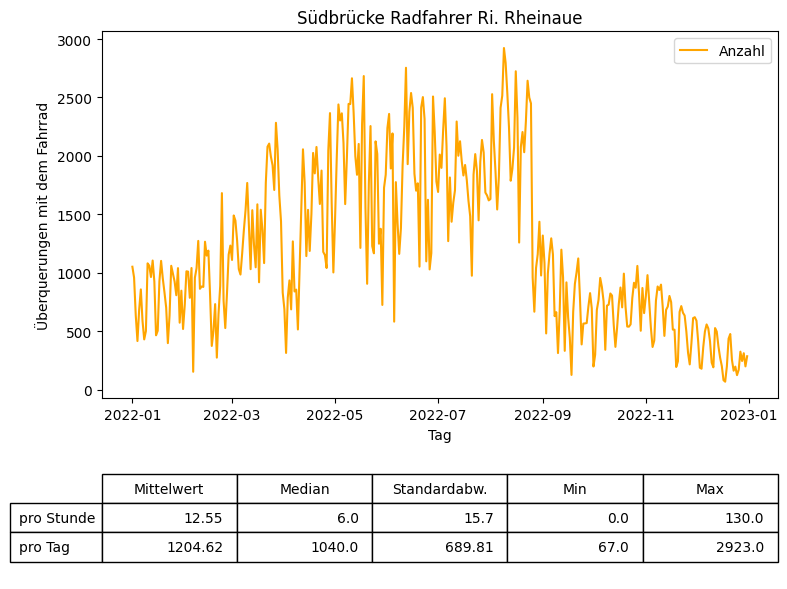

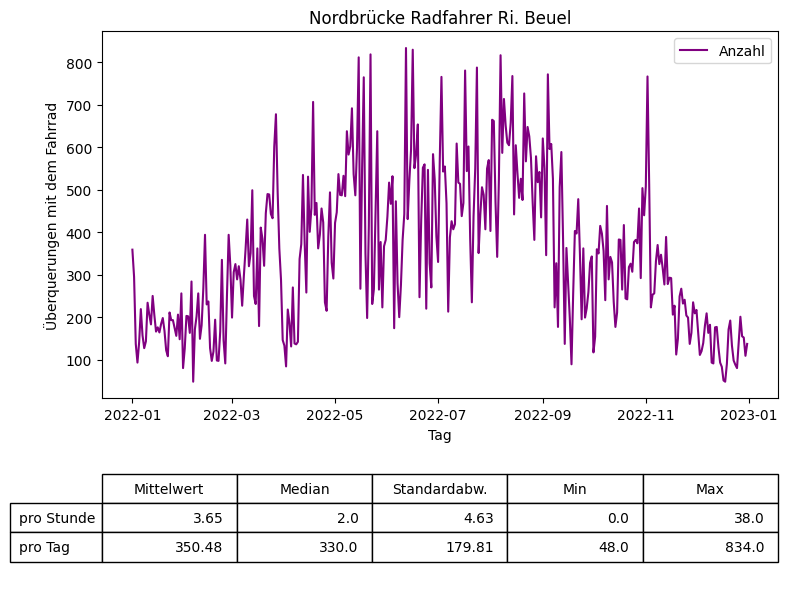

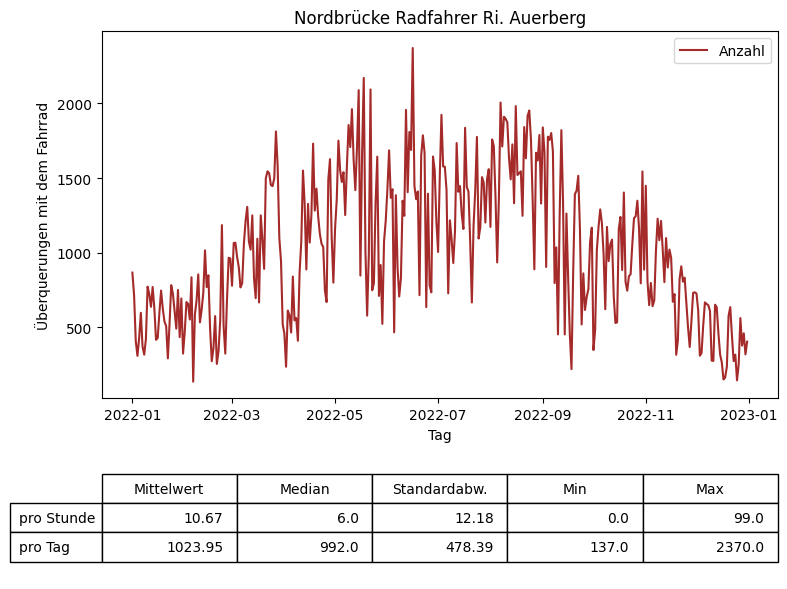

In [4]:
for name in df.columns:
   plot(name, 'Stunde')

In [5]:
import matplotlib.gridspec as gridspec

def plot_tables(columns, hourly):

    colors = ['blue', 'green', 'red', 'cyan', 'magenta', 'yellow', 'orange', 'purple', 
                  'brown', 'pink', 'gray', 'olive', 'teal', 'navy', 'lime', 'gold', 'violet', 'blue']
    
    all_dates = pd.date_range(start=df['days'].min(), end=df['days'].max())
    all_rows = []
    rows_labels = []
    fig, ax = plt.subplots()
    
    for name in columns:
        if name != 'time' and name != 'days' and name !='Time':
            x_values_per_day = df.groupby('days')[name].sum()
            x_values_per_day = x_values_per_day.reindex(all_dates, fill_value=None)
            # Zellen für die Tabelle
            x_values_per_hour = df[name]
            cells_per_hour = [x_values_per_hour.mean(), x_values_per_hour.median(),
                              x_values_per_hour.std(), x_values_per_hour.min(), x_values_per_hour.max()]
    
            cells_per_day = [x_values_per_day.mean(), x_values_per_day.median(), 
                             x_values_per_day.std(), x_values_per_day.min(), x_values_per_day.max()]
    
            # Runde die Werte für die Tabelle
            cells_per_hour = [round(value, 2) for value in cells_per_hour]
            cells_per_day = [round(value, 2) for value in cells_per_day]
            all_rows.append(cells_per_hour)
            all_rows.append(cells_per_day)
    
            rows_labels.append('{} pro {}'.format(name, hourly))
            rows_labels.append('{} pro Tag'.format(name))
    
    fig.patch.set_visible(False)
    ax.axis('off')
    ax.axis('tight')
    # Tabellenüberschriften
    titles = ['Mittelwert', 'Median', 'Standardabw.', 'Min', 'Max']
    # Tabelle erstellen
    table =ax.table(cellText=all_rows, rowLabels=rows_labels, colLabels = titles,
                               loc='center')
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1, 1.5)


/home/leon/.var/app/com.jetbrains.PyCharm-Professional/cache/JetBrains/PyCharm2024.1/demo/PyCharmLearningProject/venv/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1241: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/home/leon/.var/app/com.jetbrains.PyCharm-Professional/cache/JetBrains/PyCharm2024.1/demo/PyCharmLearningProject/venv/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1241: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


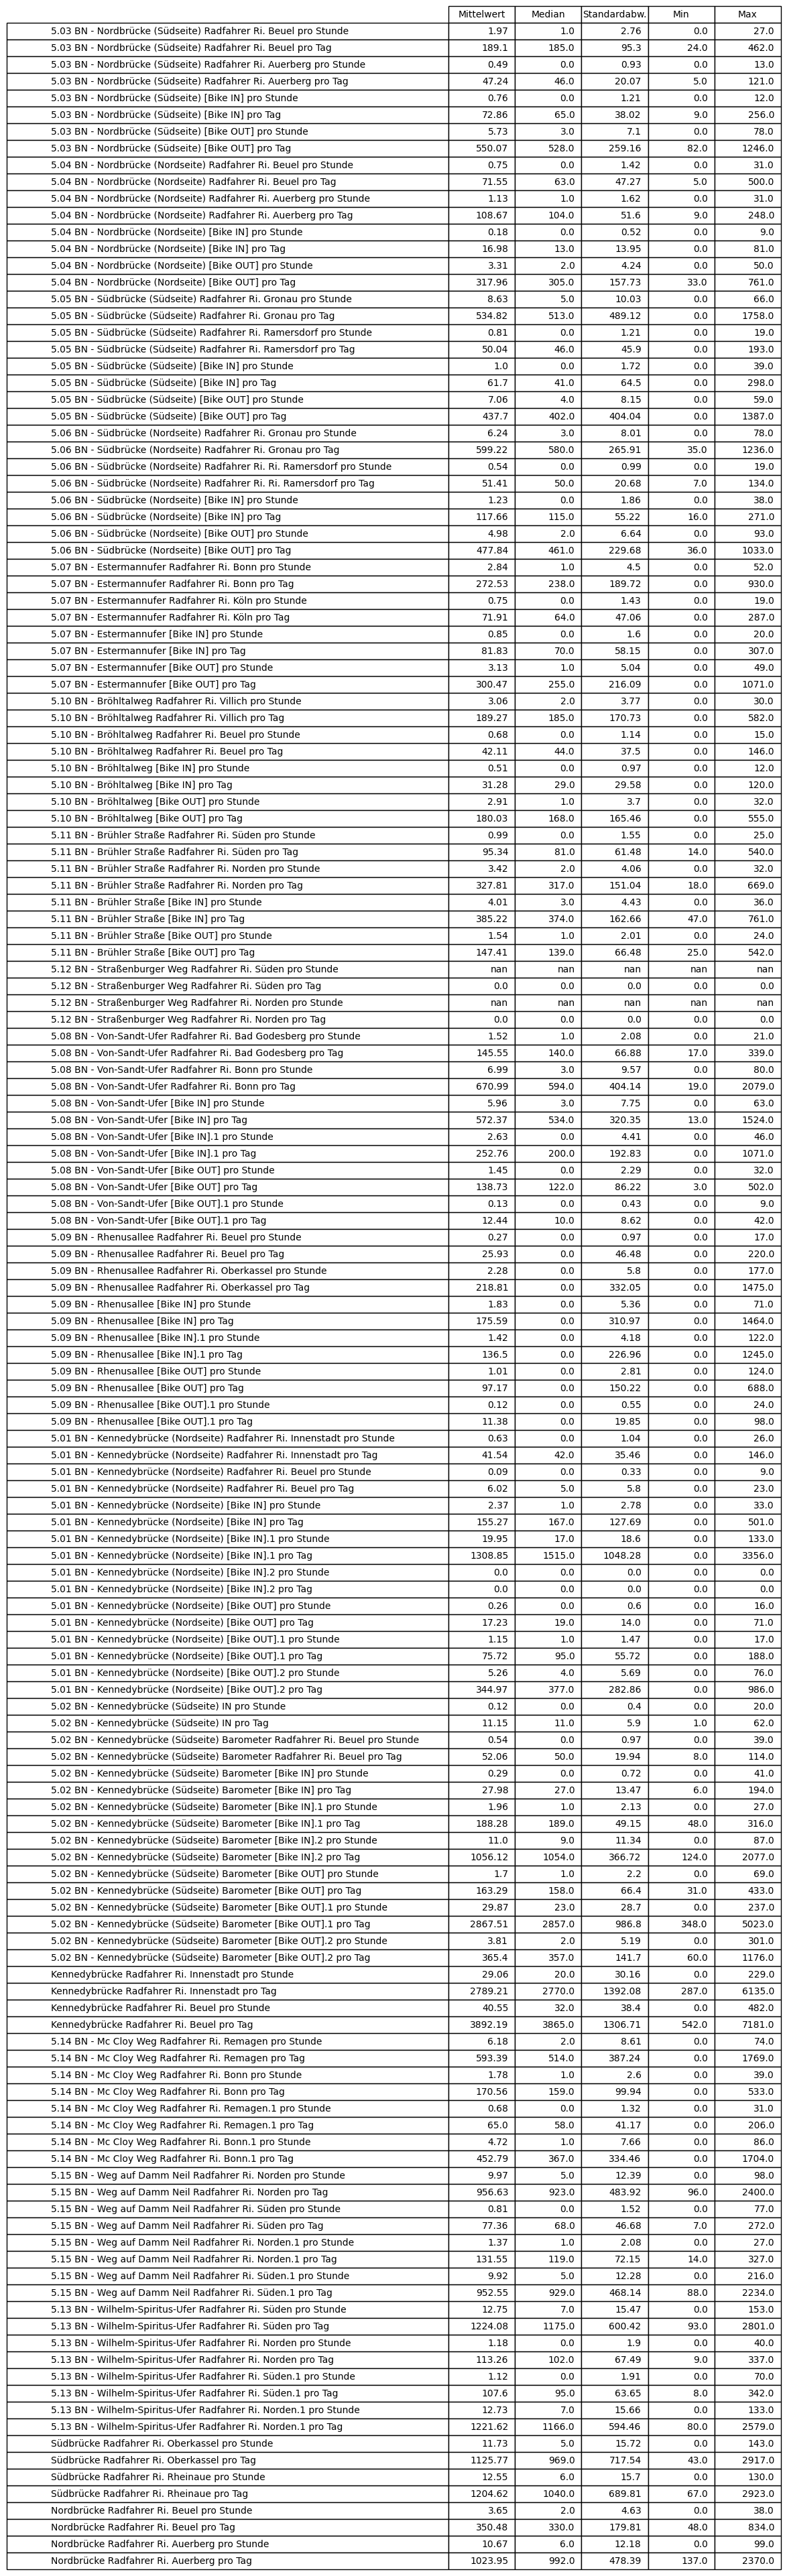

In [6]:
plot_tables(df.columns, 'Stunde')

In [8]:
import os
from pathlib import Path 

for filename in os.listdir('../Projektdatensaetze/2022'):
    if filename.endswith('.csv') and filename != 'standortinformationen_dauerzählsstellen.csv' and filename != 'FahrradBonn2022_COPY.csv':
        print(filename+'\n')
        df: pd.DataFrame = pd.read_csv('../Projektdatensaetze/2022/' + filename, sep=';|,')
        df1 = df.copy()
        df1 = df1.rename(columns={df1.columns[0]: 'time'})
        df1['time'] = pd.to_datetime(df1['time'], format='mixed')
        df1['days'] = df1['time'].dt.date
        filepath = Path('../Projektdatensaetze_fixed/2022/fixed_'+ filename)
        filepath.parent.mkdir(parents=True, exist_ok=True)  
        df1.to_csv(filepath)
    else:
        continue

FahrradBonn2022.csv



/tmp/ipykernel_1666/3791252119.py:7: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  df: pd.DataFrame = pd.read_csv('../Projektdatensaetze/2022/' + filename, sep=';|,')
